# **Arabic Punctuation Dataset المسألة الثانية**

- تقوم بعمل Mount لـGoogle Drive حتى نقرأ/نحفظ ملفات المشروع على Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


- تحميل الداتاسيت من الرابط و فك الضغط

In [2]:
!mkdir -p data
!wget -O data/UNPC-SSAC.zip "https://data.mendeley.com/public-files/datasets/2pkxckwgs3/files/4f402c76-388e-4bde-b887-f1be522001db/file_downloaded"
!unzip -o data/UNPC-SSAC.zip -d data

from pathlib import Path

DATA_PATH = Path("data/SSAC-UNPC")
MAX_LINES = 300_000

print("DATA_PATH:", DATA_PATH.resolve())
print("Exists:", DATA_PATH.exists())

--2025-12-27 07:15:34--  https://data.mendeley.com/public-files/datasets/2pkxckwgs3/files/4f402c76-388e-4bde-b887-f1be522001db/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.130.86, 162.159.133.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.130.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/24436cd0-7900-4c94-8535-80d27820f8ee [following]
--2025-12-27 07:15:34--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/24436cd0-7900-4c94-8535-80d27820f8ee
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 52.92.33.10, 3.5.69.51, 3.5.69.106, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)|52.92.33.10|:443... con

# **1. تعريف توابع معالجة و تنظيف الداتا و  normalization توابع **

In [3]:
import re
import unicodedata
from dataclasses import dataclass
from collections import Counter
from pathlib import Path
import random

**تعريف علامات الترقيم**

- يحدد **علامات الترقيم التي نريد التنبؤ بها** ويوحد أشكالها (مثلاً تحويل `.` و`۔` إلى نقطة موحدة).
- ينشئ قاموس مفردات علامات الترقيم `PUNC_VOCAB`  ثم يبني خرائط التحويل:
  - `PUNC2ID`: من الرمز إلى رقم (label id)
  - `ID2PUNC`: العكس
- يعرف `TARGET_PUNCS_SET` لتسهيل التحقق من أن الرمز علامة ترقيم هدف.



In [ ]:
TARGET_PUNCS = {"۔":".", ".":".", "،":"،", ",":"،", "؛":"؛", ";":"؛",
                ":":":", "؟":"؟", "?":"؟", "!":"!"}

PUNC_VOCAB = ["_", "،", "؛", ":", "؟", "!", "."]
PUNC2ID = {p:i for i,p in enumerate(PUNC_VOCAB)}
ID2PUNC = {i:p for p,i in PUNC2ID.items()}
TARGET_PUNCS_SET = set(PUNC_VOCAB[1:])

### التعابير المنتظمة المستخدمة في تنظيف البيانات REGEX
  - إزالة/كشف التشكيل `DIACRITICS_RE`.
  - كشف الكلمات اللاتينية `LATIN_COUNT_RE`.
  - كشف علامات ترقيم ملتصقة بالكلمات `ATTACHED_PUNC_RE`.
  - كشف تكرار/تجميع علامات الترقيم `MULTI_PUNC_DETECT_RE`.
  - كشف أكواد الأمم المتحدة (UN codes) بصيغ متعددة `UN_CODE_RE`.

In [ ]:
DIACRITICS_RE = re.compile(r"[\u0617-\u061A\u064B-\u0652\u0670\u06D6-\u06ED]")
LATIN_COUNT_RE = re.compile(r"[A-Za-zÀ-ÖØ-öø-ÿ]+")
ATTACHED_PUNC_RE = re.compile(r"[\u0600-\u06FF0-9A-Za-z][،؛:؟!\.][\u0600-\u06FF0-9A-Za-z]")
MULTI_PUNC_DETECT_RE = re.compile(r"[؟!]{2,}|\.{2,}|[،؛:]{2,}")

UN_CODE_RE = re.compile(r"""
(?<![\w/])\(? 
(?=[A-Z0-9/.\-]*\d) 
[A-Z]{1,8}(?:/[A-Z]{1,8})?(?:\.\d+)? 
(?:   
  (?:/|-) 
  (?:[A-Z]{1,12}(?:\.\d+)?|\d{1,6})
)+
\)? 
""", re.VERBOSE)

UN_PREFIX_END_RE = re.compile(r"\b[A-Z]{1,8}(?:/[A-Z]{1,8})?\.\s*$")
UN_CONT_START_RE = re.compile(r"^(?:\d+[,،]?|\d+/\d+|/\d+)\b")
LAT_DOT_END_RE   = re.compile(r"\b[A-Za-z]{1,10}\.\s*$")

AR_DIACRITICS_RE = re.compile(r"[\u0617-\u061A\u064B-\u0652]")

AR_NUM_MAP = str.maketrans("٠١٢٣٤٥٦٧٨٩", "0123456789")
HI_NUM_MAP = str.maketrans("۰۱۲۳۴۵۶۷۸۹", "0123456789")

NON_ARABIC_WORD_RE = re.compile(
    r"\b(?!CODE\b)(?!YEAR\b)(?!NUM\b)(?![\u0600-\u06FF])[^\W\d_]+",
    re.UNICODE
)

MULTI_PUNC_RE = re.compile(r"([!؟،.:;]){2,}")
WORD_COMMA_WORD_RE = re.compile(r"(\w)،(\w)")

PUNC_SET = r"[،؛:؟!\.]"
WORD_PUNC_WORD_RE = re.compile(rf"([\u0600-\u06FF])({PUNC_SET})([\u0600-\u06FF])")
WORD_PUNC_END_RE  = re.compile(rf"([\u0600-\u06FF])({PUNC_SET})(?=\s|$|[)\]\}}])")

DECIMAL_R_RE = re.compile(r"(\d)\s*ر\s*(\d)")
AR_LETTERS = r"\u0600-\u06FF"
DIGIT_AR_AFTER_RE   = re.compile(rf"(\d)([{AR_LETTERS}])")
AR_BEFORE_DIGIT_RE  = re.compile(rf"([{AR_LETTERS}])(\d)")

SPACED_NUMBER_RE = re.compile(r"(?<!\d)(\d{1,3}(?:\s+\d{1,3}){1,})(?!\d)")

YEAR_RANGE_RE2 = re.compile(r"(?<!\d)(?:19|20)\d{2}\s*[-–]\s*(?:19|20)\d{2}(?!\d)")
YEAR_RE2       = re.compile(r"(?<!\d)(?:19|20)\d{2}(?!\d)")
GEN_NUMBER_RE2 = re.compile(r"(?<!\d)\d+(?:[.,]\d+)?(?:\s+\d{1,3})*(?:\s*[-–]\s*\d+(?:[.,]\d+)?)?(?!\d)")

SPACED_CODE_FIX_RE = re.compile(r"\b([A-Z]{2,10}/\d{2,4})\s+(\d{1,4})\b")

EN_LETTERS_RE = re.compile(r"[A-Za-z]+")

SUFFIX_RE = r"[A-Z]{1,10}\.\d+"
BASE_CODE_RE = r"[A-Z]{1,8}(?:/[A-Z0-9]{1,12}(?:\.\d+)?)+"
CODE_HEAD_RE = rf"{BASE_CODE_RE}(?:-{BASE_CODE_RE})*"
CODE_WITH_SUFFIX_RE = rf"{CODE_HEAD_RE}(?:/{SUFFIX_RE})*"
CODE_SUFFIX_JOIN_RE = re.compile(rf"({CODE_WITH_SUFFIX_RE})\s*[،,]?\s*و\s*({SUFFIX_RE})\b")

- يركّز على **توحيد المسافات** حول الأقواس `()` و`[]` والفواصل/الفواصل الخاصة مثل الشرطة `-` والشرطة المائلة `/`.

In [6]:
BRACKET_BEFORE_RE = re.compile(r"([^\s\(\)\[\]])([\(\)\[\]])")
BRACKET_AFTER_RE  = re.compile(r"([\(\)\[\]])([^\s\(\)\[\]])")

DASH_AROUND_RE = re.compile(r"(?<!\d)-(?!\d)")

SLASH_AROUND_RE = re.compile(r"(?<![A-Z0-9])/|(?![A-Z0-9])/")

PAREN_BEFORE_RE = re.compile(r"([^\s(])(\()")
PAREN_AFTER_RE  = re.compile(r"(\))([^\s)])")

#### قراءة البيانات باستخدام Lazy Loading
- قراءة البيانات سطرا سطرا بدون تحميل كل الملفات في الذاكرة
- التوابع الأساسية :
  - `iter_text_files(...)`: يحدد الملفات النصية داخل مجلد.
  - `iter_lines(...)`: يولد (path, line) لكل سطر.
  - `iter_lines_merged_un(...)`: نسخة خاصة معالجة أسطر تتعلق بأكواد UN.
  - هذه الاكواد تحتوي نقاط و هي مشكلة لانها ليست علامات ترقيم لذلك قمنا بمعالجنها
  - هذه الاكواد تاتي بعض الاحيان مقسمة على اكثر من سطر لذلك لدينا تابع `iter_lines_merged_un`


In [7]:
def iter_text_files(data_path: Path):
    for p in sorted(data_path.rglob("*.txt")):
        yield p

def iter_lines(files):
    for fp in files:
        with fp.open("r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                yield fp.name, line.rstrip("\n")

def iter_lines_merged_un(files):
    prev = None
    prev_file = None

    for fname, line in iter_lines(files):
        cur = line.rstrip("\n").strip()

        if prev is None:
            prev, prev_file = cur, fname
            continue

        if fname != prev_file:
            yield prev_file, prev
            prev, prev_file = cur, fname
            continue

        prev_str = prev.strip()

        if UN_PREFIX_END_RE.search(prev_str) and UN_CONT_START_RE.search(cur):
            joiner = "" if re.match(r"^\d", cur) else " "
            prev = prev_str + joiner + cur
            continue

        if LAT_DOT_END_RE.search(prev_str) and re.match(r"^\d+[,،]?", cur):
            prev = prev_str + cur
            continue

        yield prev_file, prev
        prev, prev_file = cur, fname

    if prev is not None:
        yield prev_file, prev

#### تعريف توابع normalizations
- أهم المراحل الموجودة
  - **مسافات/فواصل**: `space_brackets_and_separators`, `collapse_runs`.
  - **توحيد الترقيم**: `normalize_punctuation`, `normalize_repeated_punc`, `normalize_mixed_punctuation`, `fix_word_comma_word`.
  - **أرقام**: `normalize_digits`, `normalize_spaced_numbers`, `separate_digits_and_arabic`, `replace_numbers_and_years`.
  - **تشكيل ورموز**: `remove_diacritics`, `normalize_arabic_letters_and_remove_symbols`.
  - **لاتيني**: `replace_latin`, `replace_english_letters_with_foreign`.
  - **UN codes**: `replace_un_codes` + توابع تصحيح المسافات الداخلية.
  - **حروف نادرة**: `build_rare_char_set`, `remove_rare_chars_safe`.
  - وفي النهاية `preprocess_line` التي تجمع كل الخطوات وتُرجع النص المنظّف.

In [8]:
def space_brackets_and_separators(text: str) -> str:
    text = BRACKET_BEFORE_RE.sub(r"\1 \2", text)
    text = BRACKET_AFTER_RE.sub(r"\1 \2", text)

    text = DASH_AROUND_RE.sub(" - ", text)

    text = SLASH_AROUND_RE.sub(" / ", text)

    return text

def normalize_punctuation(text):
    return (
        text.replace(";", "؛")
            .replace(",", "،")
            .replace("?", "؟")
    )

def normalize_digits(text):
    text = text.translate(AR_NUM_MAP)
    text = text.translate(HI_NUM_MAP)
    return text

def remove_diacritics(text):
    return AR_DIACRITICS_RE.sub("", text)

def normalize_repeated_punc(text):
    return MULTI_PUNC_RE.sub(r"\1", text)

def fix_word_comma_word(text):
    return WORD_COMMA_WORD_RE.sub(r"\1 ، \2", text)

def normalize_mixed_punctuation(text):
    text = re.sub(r"[!?]{2,}", "?", text)
    text = re.sub(r"[.]{2,}", ".", text)
    return text

def normalize_spaced_numbers(text: str) -> str:
    def repl(m):
        seq = m.group(1)
        parts = seq.split()
        if any((not p.isdigit()) or len(p) > 3 for p in parts):
            return seq
        return "".join(reversed(parts))
    return SPACED_NUMBER_RE.sub(repl, text)

def replace_latin(text):
    return NON_ARABIC_WORD_RE.sub("لاتيني", text)

def collapse_runs(tokens, labels, run_token="LAT", collapsed_token="[FOREIGN]"):
    new_toks, new_labs = [], []
    i = 0
    n = len(tokens)

    while i < n:
        if tokens[i] != run_token:
            new_toks.append(tokens[i])
            new_labs.append(labels[i])
            i += 1
            continue

        j = i
        while j < n and tokens[j] == run_token:
            j += 1

        new_toks.append(collapsed_token)
        new_labs.append(labels[j - 1])
        i = j

    return new_toks, new_labs

def space_word_punctuation(text: str) -> str:
    text = WORD_PUNC_WORD_RE.sub(r"\1 \2 \3", text)
    text = WORD_PUNC_END_RE.sub(r"\1 \2", text)
    return text

def normalize_decimal_r(text: str) -> str:
    return DECIMAL_R_RE.sub(r"\1.\2", text)

def separate_digits_and_arabic(text: str) -> str:
    text = DIGIT_AR_AFTER_RE.sub(r"\1 \2", text)
    text = AR_BEFORE_DIGIT_RE.sub(r"\1 \2", text)
    return text

def replace_numbers_and_years(text: str) -> str:
    text = YEAR_RANGE_RE2.sub(" سنة", text)
    text = YEAR_RE2.sub(" سنة", text)
    text = GEN_NUMBER_RE2.sub(" رقم", text)
    return text

def fix_spaced_codes(text: str) -> str:
    return SPACED_CODE_FIX_RE.sub(r"\1/\2", text)

def replace_un_codes(text: str, token="كود") -> str:
    text = fix_spaced_codes(text)

    def repl(m):
        span = m.group(0)
        lead = "(" if span.startswith("(") else ""
        tail = ")" if span.endswith(")") else ""
        return f"{lead}{token}{tail}"

    return UN_CODE_RE.sub(repl, text)

def fix_un_code_internal_spacing(text: str) -> str:
    text = re.sub(r"(\b[A-Z]{1,8}(?:/[A-Z]{1,8})*\.)\s+(\d)", r"\1\2", text)
    text = re.sub(
        r"\b([A-Za-z]{1,10})\.\s*(\d+)\b",
        lambda m: f"{m.group(1).upper()}.{m.group(2)}",
        text
    )
    return text

def fix_un_code_conjunction(text: str) -> str:
    return re.sub(r"(/[\d]{1,6})\s*و\s*([A-Z]{1,10}\.\d+)\b", r"\1/\2", text)

def fix_un_code_suffix_conjunction(text: str) -> str:
    while True:
        new = CODE_SUFFIX_JOIN_RE.sub(r"\1/\2", text)
        if new == text:
            return text
        text = new

def replace_english_letters_with_foreign(text: str, token: str = "اجنبي") -> str:
    if not text:
        return text
    text = EN_LETTERS_RE.sub(token, text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

ARABIC_LETTER_NORMALIZE_MAP = str.maketrans({
    "أ": "ا",
    "إ": "ا",
    "آ": "ا",
    "ؤ": "و",
    "ئ": "ي",
    '∙': '.',
})

WEIRD_SYMBOLS_TO_SPACE = [
    '•','■','◂','ﱞ','±','⋆','٪','@','»','ﱠ','ﱢ','`','ﱡ','●','♦','«',
    'ّ','َ','ِ','ُ','ٌ','/','{','é','+','=','\\'
]
SPACE_TRANSLATION = {ord(ch): " " for ch in WEIRD_SYMBOLS_TO_SPACE}

def normalize_arabic_letters_and_remove_symbols(text: str) -> str:
    text = unicodedata.normalize("NFKC", text)
    text = text.translate(ARABIC_LETTER_NORMALIZE_MAP)
    text = text.translate(SPACE_TRANSLATION)
    text = re.sub(r"\s+", " ", text).strip()
    return text


PROTECTED_TOKENS = {
    "كود",
    "سنة",
    "رقم",
    "اجنبي",
}

def is_arabic_char(ch: str) -> bool:
    o = ord(ch)
    return (
        0x0600 <= o <= 0x06FF or
        0x0750 <= o <= 0x077F or
        0x08A0 <= o <= 0x08FF
    )

def is_allowed_punc(ch: str) -> bool:
    return ch in TARGET_PUNCS_SET

def build_rare_char_set(
    train_files,
    min_freq: int = 5,
) -> set:
    counts = count_all_characters_cleaned(
        train_files,
        merged_un=True,
        ignore_spaces=True,
    )

    rare = set()
    for ch, c in counts.items():
        if c >= min_freq:
            continue
        if is_allowed_punc(ch):
            continue
        if is_arabic_char(ch):
            continue
        rare.add(ch)

    return rare

def remove_rare_chars_safe(
    text: str,
    rare_chars: set,
) -> str:
    if not text:
        return text

    out = []
    tokens = text.split()

    for tok in tokens:
        if tok in PROTECTED_TOKENS:
            out.append(tok)
            continue

        clean_tok = []
        for ch in tok:
            if ch in rare_chars:
                continue
            clean_tok.append(ch)

        if clean_tok:
            out.append("".join(clean_tok))

    return " ".join(out)



#### تعريف تابع `preprocess_line`
- هذا  التابع يعالج سطر واحد كامل

In [9]:
def preprocess_line(
    text: str,
    do_remove_diacritics: bool = True,
    do_replace_latin: bool = True,
):
    if not text or not text.strip():
        return text

    text = normalize_digits(text)
    text = normalize_punctuation(text)

    text = normalize_decimal_r(text)
    text = separate_digits_and_arabic(text)

    if do_remove_diacritics:
        text = remove_diacritics(text)

    text = fix_un_code_internal_spacing(text)
    text = fix_un_code_conjunction(text)
    text = fix_un_code_suffix_conjunction(text)
    text = replace_un_codes(text, token=" كود")

    text = space_brackets_and_separators(text)

    text = normalize_spaced_numbers(text)
    text = replace_numbers_and_years(text)

    text = space_word_punctuation(text)
    text = fix_word_comma_word(text)

    text = normalize_repeated_punc(text)
    text = normalize_mixed_punctuation(text)

    if do_replace_latin:
        text = replace_latin(text)

    # text = normalize_arabic_letters_and_remove_symbols(text)
    text = replace_english_letters_with_foreign(text)

    text = re.sub(r"\s+", " ", text).strip()
    return text

#### توابع لإحصاء توزيع الحروف و الرموز على البيانات (قبل وبعد التنظيف)

 - `count_all_characters(...)`: يعد كل المحارف كما هي.
  - `count_all_characters_cleaned(...)`: يعد المحارف بعد `preprocess_line` (أي بعد التطبيع).

- ساعدتنا هذه التوابع في اكتشاف الرموز الغريبة و اتخاذ قرار حذفها او استبدالها في ال Vocabulary

In [10]:
def count_all_characters(files_list, max_lines=MAX_LINES):
    char_counter = Counter()
    for i, (_, line) in enumerate(iter_lines(files_list)):
        if i >= max_lines:
            break
        char_counter.update(line)
    return char_counter

def count_all_characters_cleaned(files_list, max_lines=MAX_LINES,
                                 merged_un=True,
                                 ignore_spaces=True):
    char_counter = Counter()
    line_iter = iter_lines_merged_un(files_list) if merged_un else iter_lines(files_list)

    for i, (_, line) in enumerate(line_iter):
        if i >= max_lines:
            break

        cleaned = preprocess_line(line)
        if not cleaned or not cleaned.strip():
            continue

        if ignore_spaces:
            cleaned = cleaned.replace(" ", "")

        char_counter.update(cleaned)

    return char_counter


#### تنميط البيانات و تقسيمها الى بيانات تدريب و بيانات اختبار على مستوى الملفات لتفادي data leakage  

- `line_to_tokens_labels` هذا التابع يحول السطر الى tokens, labels و يستخرج علامات الترقيم الاصلية من السطر
- `split_files` يقسم الملفات الى بيانات تدريب و تحقق

In [11]:
def line_to_tokens_labels(processed_line: str):
    for p in ["،", "؛", ":", "؟", "!", "."]:
        processed_line = processed_line.replace(p, f" {p} ")

    parts = processed_line.split()

    tokens, labels = [], []
    i = 0
    while i < len(parts):
        w = parts[i]
        if w in TARGET_PUNCS_SET:
            i += 1
            continue

        tokens.append(w)
        lab = PUNC2ID["_"]
        if i + 1 < len(parts) and parts[i + 1] in TARGET_PUNCS_SET:
            lab = PUNC2ID[parts[i + 1]]
        labels.append(lab)
        i += 1

    return tokens, labels

def split_files(files, val_ratio=0.2, seed=42):
    files = list(files)
    rnd = random.Random(seed)
    rnd.shuffle(files)
    n_val = max(1, int(len(files) * val_ratio))
    return files[n_val:], files[:n_val]

- `iter_examples(...)`: يولد أمثلة جاهزة (tokens/labels) لاستخدامها في بناء vocab أو التدريب.

In [12]:
def iter_examples(files, rare_chars=None, max_lines=None):
    """
    yield: dict(raw_text, processed_text, tokens, labels, file)
    """
    n = 0
    for fname, raw in iter_lines_merged_un(files):
        if max_lines is not None and n >= max_lines:
            break
        n += 1

        raw_text = raw.strip()
        if not raw_text:
            continue

        processed = preprocess_line(raw_text)

        if rare_chars is not None:
            processed = remove_rare_chars_safe(processed, rare_chars)

        if not processed or not processed.strip():
            continue

        toks, labs = line_to_tokens_labels(processed)
        if not toks:
            continue

        yield {
            "file": fname,
            "raw_text": raw_text,
            "processed_text": processed,
            "tokens": toks,
            "labels": labs
        }

# **2. تحليل البيانات قبل و بعد التنظيف و المعالجة EDA**

- بداية قمنا بتقسيم البيانات الى تدريب و تحقق



In [13]:
import statistics as stats
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pickle

files = list(iter_text_files(DATA_PATH))
print("num_files:", len(files))
train_files, val_files = split_files(files, val_ratio=0.2, seed=42)
print("Files:", len(files), "| train:", len(train_files), "| val:", len(val_files))


num_files: 79
Files: 79 | train: 64 | val: 15


#### لكي لا نقوم ببناء rare_chars كل مرة عرفنا توابع لحفظها في الدرايف

In [14]:
from pathlib import Path
import pickle

RARE_CHAR_PATH = "/content/punctuation_project/punctuation_project/rare_chars_min5_train_only.pkl"

def save_rare_char_set(rare_chars: set, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(rare_chars, f)

def load_rare_char_set(path):
    with open(path, "rb") as f:
        return pickle.load(f)

rare_chars = build_rare_char_set(train_files, min_freq=5)
save_rare_char_set(rare_chars, RARE_CHAR_PATH)

print(f"Saved {len(rare_chars)} rare chars → {RARE_CHAR_PATH}")


Saved 28 rare chars → /content/punctuation_project/punctuation_project/rare_chars_min5_train_only.pkl


- تحميل ال rare_chars من الدرايف و التاكد من محتواها

In [15]:
rare_chars_loaded = load_rare_char_set(str(RARE_CHAR_PATH))

print("Loaded type:", type(rare_chars_loaded))
print("Number of rare chars:", len(rare_chars_loaded))
print("Sample:", list(rare_chars_loaded)[:20])


Loaded type: <class 'set'>
Number of rare chars: 28
Sample: ['ﺏ', 'ﺪ', 'ﺎ', '…', 'μ', 'ﻨ', 'ﻠ', '†', 'ﻸ', 'ö', 'ﺗ', 'ﻧ', 'ﻕ', 'ﲔ', '§', 'é', 'ä', 'ﺼ', 'ﻌ', 'ﻮ']


- تابع `analyze_line` يحلل سطر كامل و يستخرج منه احصاءات هامة

In [16]:
def analyze_line(line: str):
    raw = line.strip()
    if not raw:
        return {"empty": True}

    char_len = len(raw)
    word_count = len(raw.split())

    punc_counts = Counter()
    for ch in raw:
        if ch in TARGET_PUNCS:
            punc_counts[TARGET_PUNCS[ch]] += 1

    return {
        "empty": False,
        "char_len": char_len,
        "word_count": word_count,
        "punc_counts": punc_counts,
        "has_diacritics": bool(DIACRITICS_RE.search(raw)),
        "latin_count": len(LATIN_COUNT_RE.findall(raw)),
        "has_un_code": bool(UN_CODE_RE.search(raw)),
        "has_attached_punc": bool(ATTACHED_PUNC_RE.search(raw)),
        "has_multi_punc": bool(MULTI_PUNC_DETECT_RE.search(raw)),
    }

#### تحليل قبل تنظيف البيانات EDA

- يجمع إحصاءات سريعة عن البيانات الخام مثل:
  - أطوال الأسطر (`char_len`)
  - عدد الكلمات
  - عدّ علامات الترقيم
  - مشاكل شائعة: وجود تشكيل، كلمات لاتينية، أكواد UN، علامات ملتصقة، تكرار ترقيم...
- الهدف: معرفة حجم المشاكل قبل تطبيق الـpreprocessing.

In [17]:
total_lines = 0
empty_lines = 0

char_lens = []
word_counts = []
punc_total = Counter()
issues = Counter()

for i, (_, line) in enumerate(iter_lines(train_files)):
    if i >= MAX_LINES:
        break

    total_lines += 1
    info = analyze_line(line)

    if info.get("empty"):
        empty_lines += 1
        continue

    char_lens.append(info["char_len"])
    word_counts.append(info["word_count"])
    punc_total.update(info["punc_counts"])

    if info["has_diacritics"]:
        issues["diacritics_lines"] += 1
    if info["latin_count"] > 0:
        issues["latin_lines"] += 1
    if info["has_un_code"]:
        issues["un_code_lines"] += 1
    if info["has_attached_punc"]:
        issues["attached_punc_lines"] += 1
    if info["has_multi_punc"]:
        issues["multi_punc_lines"] += 1

print("=== Basic RAW EDA Stats ===")
print("Total analyzed lines:", total_lines)
print("Empty lines:", empty_lines, f"({empty_lines/max(total_lines,1):.2%})")
print("Avg char length:", round(stats.mean(char_lens), 2) if char_lens else 0)
print("Avg word count:", round(stats.mean(word_counts), 2) if word_counts else 0)

print("\nIssues summary (RAW):")
for k, v in issues.most_common():
    print(f"{k}: {v}")


=== Basic RAW EDA Stats ===
Total analyzed lines: 300000
Empty lines: 0 (0.00%)
Avg char length: 162.12
Avg word count: 26.28

Issues summary (RAW):
diacritics_lines: 73985
latin_lines: 18542
un_code_lines: 7074
attached_punc_lines: 2450
multi_punc_lines: 4


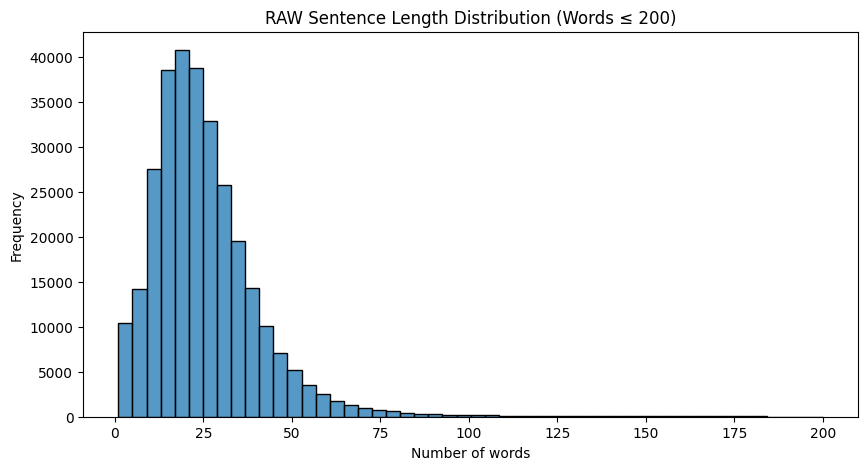

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot([w for w in word_counts if w <= 200], bins=50)
plt.title("RAW Sentence Length Distribution (Words ≤ 200)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

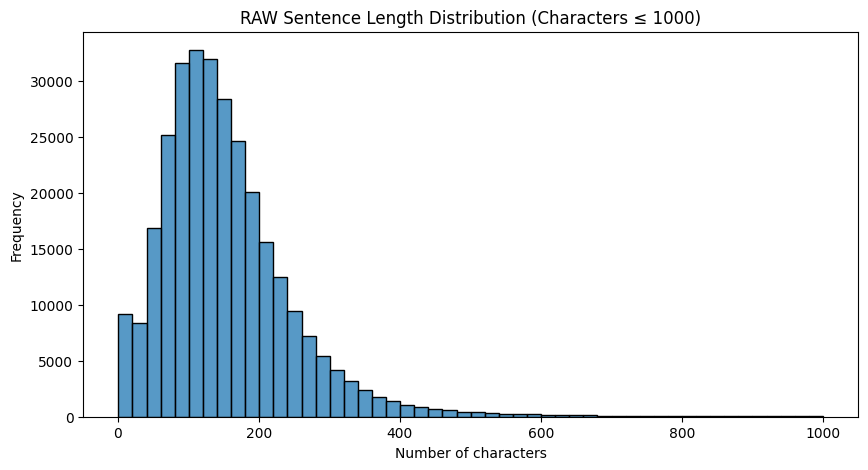

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot([c for c in char_lens if c <= 1000], bins=50)
plt.title("RAW Sentence Length Distribution (Characters ≤ 1000)")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")
plt.show()


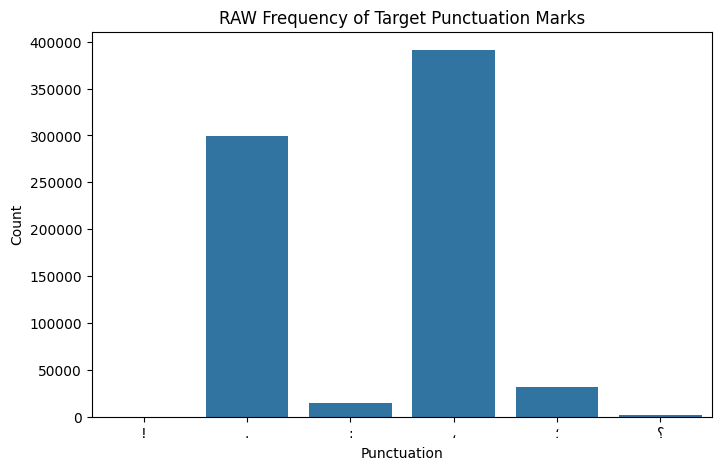

In [ ]:
punc_items = sorted(punc_total.items())
labels = [k for k, _ in punc_items]
counts = [v for _, v in punc_items]

plt.figure(figsize=(8, 5))
sns.barplot(x=labels, y=counts)
plt.title("RAW Frequency of Target Punctuation Marks")
plt.xlabel("Punctuation")
plt.ylabel("Count")
plt.show()

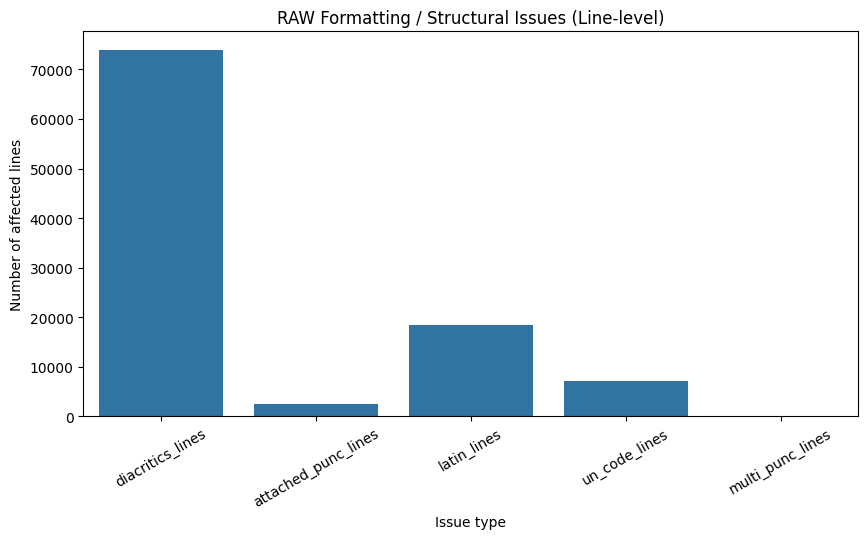

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=list(issues.keys()), y=list(issues.values()))
plt.title("RAW Formatting / Structural Issues (Line-level)")
plt.xlabel("Issue type")
plt.ylabel("Number of affected lines")
plt.xticks(rotation=30)
plt.show()

In [ ]:
print("\nRAW: Counting all characters...")
global_char_counts = count_all_characters(train_files)
print(f"Unique chars (RAW): {len(global_char_counts)}")
print("\n--- RAW most common chars ---")
for char, count in global_char_counts.most_common(161):
    print(f"char: {repr(char)} | count: {count}")


RAW: Counting all characters...
Unique chars (RAW): 230

--- RAW most common chars ---
char: ' ' | count: 7584438
char: 'ا' | count: 7394151
char: 'ل' | count: 4827214
char: 'ي' | count: 2894736
char: 'م' | count: 2668307
char: 'ت' | count: 2087495
char: 'و' | count: 2052538
char: 'ن' | count: 1910916
char: 'ر' | count: 1598665
char: 'ة' | count: 1487394
char: 'د' | count: 1270231
char: 'ع' | count: 1256887
char: 'ب' | count: 1129388
char: 'ف' | count: 975958
char: 'ق' | count: 900000
char: 'س' | count: 844163
char: 'ه' | count: 678590
char: 'ح' | count: 609700
char: 'ج' | count: 593991
char: 'ك' | count: 591801
char: '،' | count: 390276
char: 'ش' | count: 334741
char: 'ط' | count: 324597
char: 'ص' | count: 314319
char: 'ى' | count: 312874
char: '.' | count: 299575
char: 'خ' | count: 263832
char: 'ذ' | count: 250454
char: 'ض' | count: 246873
char: 'ز' | count: 228087
char: 'ث' | count: 185732
char: 'ئ' | count: 182996
char: '0' | count: 172110
char: 'غ' | count: 164664
char: '1' | cou

#### تحليل بعد تنظيف البيانات EDA

- يعيد نفس الإحصاءات تقريبا لكن بعد تمرير النص عبر `preprocess_line`.

In [ ]:
total_lines_c = 0
empty_lines_c = 0

char_lens_c = []
word_counts_c = []
punc_total_c = Counter()
issues_c = Counter()

for i, (_, line) in enumerate(iter_lines_merged_un(train_files)):
    if i >= MAX_LINES:
        break

    total_lines_c += 1
    cleaned = preprocess_line(line)

    if not cleaned or not cleaned.strip():
        empty_lines_c += 1
        continue

    info = analyze_line(cleaned)

    char_lens_c.append(info["char_len"])
    word_counts_c.append(info["word_count"])
    punc_total_c.update(info["punc_counts"])

    if info["latin_count"] > 0:
        issues_c["latin_lines"] += 1
    if info["has_un_code"]:
        issues_c["un_code_lines"] += 1
    if info["has_attached_punc"]:
        issues_c["attached_punc_lines"] += 1
    if info["has_multi_punc"]:
        issues_c["multi_punc_lines"] += 1

print("\n=== Basic CLEANED EDA Stats ===")
print("Total analyzed lines:", total_lines_c)
print("Empty lines after preprocess:", empty_lines_c, f"({empty_lines_c/max(total_lines_c,1):.2%})")
print("Avg char length:", round(stats.mean(char_lens_c), 2) if char_lens_c else 0)
print("Avg word count:", round(stats.mean(word_counts_c), 2) if word_counts_c else 0)

print("\nIssues summary (CLEANED):")
for k, v in issues_c.most_common():
    print(f"{k}: {v}")



=== Basic CLEANED EDA Stats ===
Total analyzed lines: 300000
Empty lines after preprocess: 0 (0.00%)
Avg char length: 169.26
Avg word count: 30.4

Issues summary (CLEANED):
attached_punc_lines: 39
latin_lines: 5


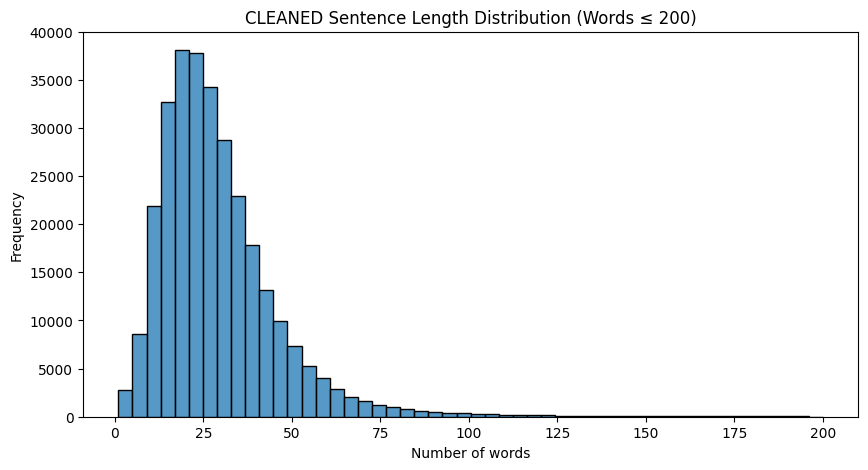

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot([w for w in word_counts_c if w <= 200], bins=50)
plt.title("CLEANED Sentence Length Distribution (Words ≤ 200)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

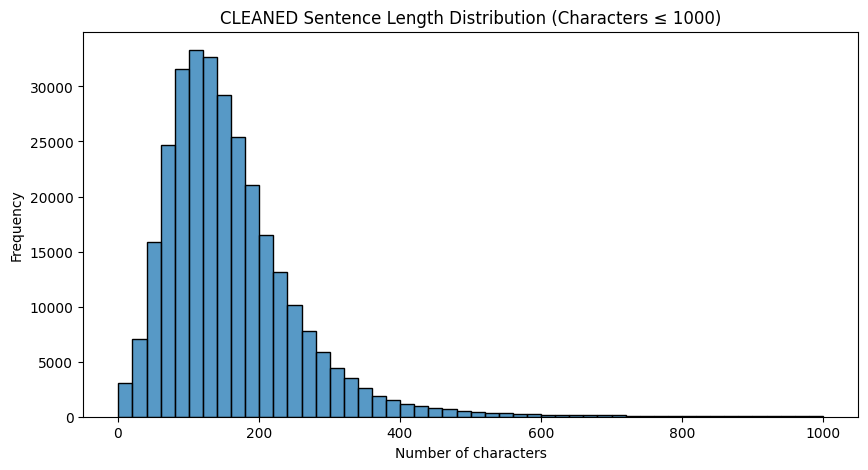

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot([c for c in char_lens_c if c <= 1000], bins=50)
plt.title("CLEANED Sentence Length Distribution (Characters ≤ 1000)")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")
plt.show()


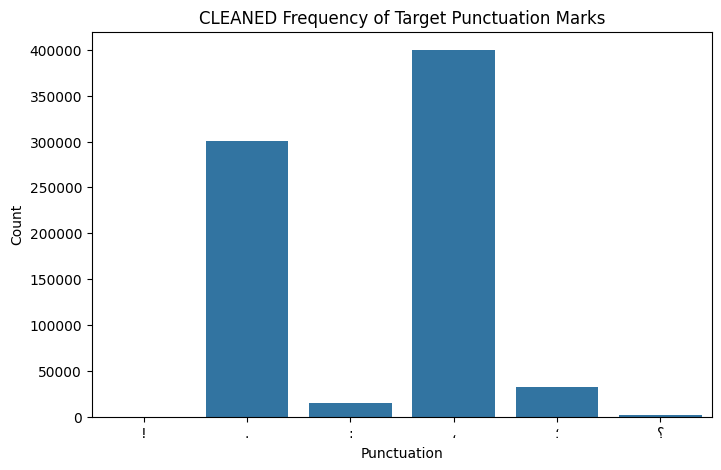

In [ ]:
punc_items_c = sorted(punc_total_c.items())
labels_c = [k for k, _ in punc_items_c]
counts_c = [v for _, v in punc_items_c]

plt.figure(figsize=(8, 5))
sns.barplot(x=labels_c, y=counts_c)
plt.title("CLEANED Frequency of Target Punctuation Marks")
plt.xlabel("Punctuation")
plt.ylabel("Count")
plt.show()

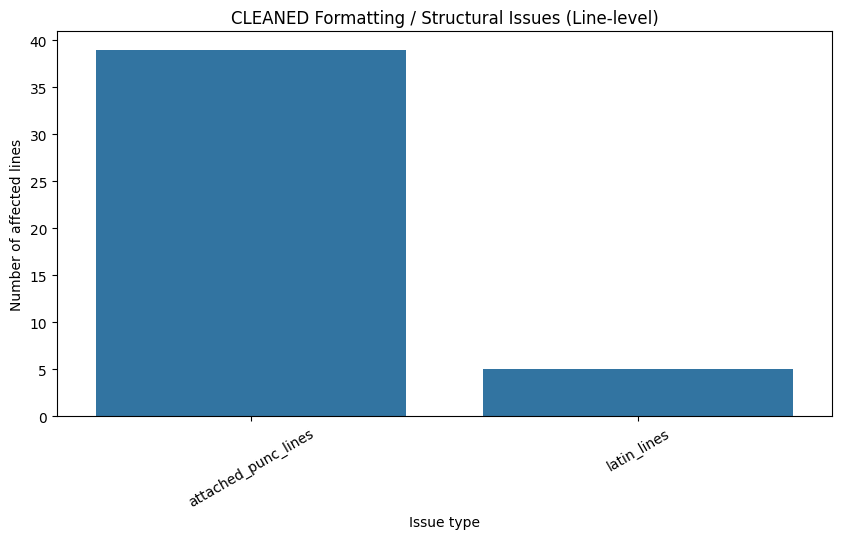

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=list(issues_c.keys()), y=list(issues_c.values()))
plt.title("CLEANED Formatting / Structural Issues (Line-level)")
plt.xlabel("Issue type")
plt.ylabel("Number of affected lines")
plt.xticks(rotation=30)
plt.show()

In [ ]:
print("\nCLEANED: Counting all characters (ignore spaces by default)...")
global_char_counts_c = count_all_characters_cleaned(train_files, merged_un=True, ignore_spaces=True)
print(f"Unique chars (CLEANED, no spaces): {len(global_char_counts_c)}")
print("\n--- CLEANED most common chars ---")
for char, count in global_char_counts_c.most_common(161):
    print(f"char: {repr(char)} | count: {count}")


CLEANED: Counting all characters (ignore spaces by default)...
Unique chars (CLEANED, no spaces): 98

--- CLEANED most common chars ---
char: 'ا' | count: 7591471
char: 'ل' | count: 4959186
char: 'ي' | count: 2988998
char: 'م' | count: 2959866
char: 'ت' | count: 2150291
char: 'و' | count: 2113094
char: 'ن' | count: 2044198
char: 'ر' | count: 1867679
char: 'ة' | count: 1592992
char: 'د' | count: 1312261
char: 'ع' | count: 1290433
char: 'ب' | count: 1157999
char: 'ق' | count: 1157260
char: 'ف' | count: 1000570
char: 'س' | count: 935398
char: 'ه' | count: 697470
char: 'ح' | count: 626983
char: 'ك' | count: 618659
char: 'ج' | count: 609925
char: '،' | count: 399682
char: 'ش' | count: 343079
char: 'ط' | count: 332639
char: 'ص' | count: 322341
char: 'ى' | count: 321480
char: '.' | count: 300332
char: 'خ' | count: 271036
char: 'ذ' | count: 257997
char: 'ض' | count: 255074
char: 'ز' | count: 233501
char: 'ث' | count: 189354
char: 'ئ' | count: 187888
char: 'غ' | count: 169029
char: 'ء' | count

#### نستخدم التابع `iter_examples` للتحقق من المعالجات

In [18]:
MAX_TEST = 15
for i, ex in enumerate(iter_examples(train_files, rare_chars=rare_chars, max_lines=MAX_TEST)):
    print("="*70)
    print("RAW:", ex["raw_text"])
    print("PRO:", ex["processed_text"])
    print("TOKS:", ex["tokens"][:30])
    print("LABS:", [ID2PUNC[x] for x in ex["labels"][:30]])

RAW: واشار حزب تجمع الهوفيتيين الى ان اللجنة الانتخابية عملت في ظروف عسيرة للغاية، بالنظر الى حظر التجول، والعقبات التي اقامها مؤيدو السيد غباغبو في اللجنة امام اعلان النتائج، والوجود المعيق لقوات الدفاع والامن في مقر اللجنة.
PRO: واشار حزب تجمع الهوفيتيين الى ان اللجنة الانتخابية عملت في ظروف عسيرة للغاية ، بالنظر الى حظر التجول ، والعقبات التي اقامها مؤيدو السيد غباغبو في اللجنة امام اعلان النتائج ، والوجود المعيق لقوات الدفاع والامن في مقر اللجنة .
TOKS: ['واشار', 'حزب', 'تجمع', 'الهوفيتيين', 'الى', 'ان', 'اللجنة', 'الانتخابية', 'عملت', 'في', 'ظروف', 'عسيرة', 'للغاية', 'بالنظر', 'الى', 'حظر', 'التجول', 'والعقبات', 'التي', 'اقامها', 'مؤيدو', 'السيد', 'غباغبو', 'في', 'اللجنة', 'امام', 'اعلان', 'النتائج', 'والوجود', 'المعيق']
LABS: ['_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '،', '_', '_', '_', '،', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '،', '_', '_']
RAW: واوضح الحزب ان قانون الانتخابات لا يحدد موعدا نهائيا لاعلان النتائج، بل لنقل محاضر الاجتماعات الى المج

# **3. Modeling النماذج**

#### **بناء ال Vocabulary**




- تابع `build_vocab_from_stream` يبني ال vocabulary من الملفات

- نقوم ببناء vocab من بيانات التدريب فقط لتجنب data leakage تسرب البيانات
- بالتالي نمرر للتابع فقط train_files

In [ ]:
def build_vocab_from_stream(files, max_lines=200_000, min_freq=2, max_vocab=50_000):
    cnt = Counter()
    n = 0
    for ex in iter_examples(files, rare_chars=rare_chars, max_lines=max_lines):
        cnt.update(ex["tokens"])
        n += 1

    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for tok, f in cnt.most_common():
        if f < min_freq:
            continue
        if tok in vocab:
            continue
        vocab[tok] = len(vocab)
        if len(vocab) >= max_vocab:
            break

    return vocab, cnt

vocab, tok_freq = build_vocab_from_stream(train_files, max_lines=6000000, min_freq=2, max_vocab=75_000)
id2tok = {i:t for t,i in vocab.items()}
print("Vocab size:", len(vocab))

- تابع لحفظ ال vocab التي تم بناءها في الدرايف كي لا نضطر لبنائها كل مرة

In [ ]:
import os
import pickle

BASE_DIR = "/content/drive/MyDrive/punctuation_vocabulary"
VOCAB_PATH = os.path.join(BASE_DIR, "vocabulary_75K_v2.pkl")

os.makedirs(BASE_DIR, exist_ok=True)

with open(VOCAB_PATH, "wb") as f:
    pickle.dump(vocab, f)

print("✅ Vocab saved to:", VOCAB_PATH)


- قراءة ال vocab التي تم بنائها و حفظها في الدرايف و التاكد من محتواها

In [21]:
import os
import pickle

BASE_DIR = "/content/drive/MyDrive/"
VOCAB_PATH = os.path.join(BASE_DIR, "vocabulary_75K_v2.pkl")

with open(VOCAB_PATH, "rb") as f:
    vocab = pickle.load(f)

print("Vocab loaded")
print("Vocab size:", len(vocab))
list(vocab.values())[:10]



Vocab loaded
Vocab size: 75000


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

- تضبط ثوابت/مسارات مهمّة مثل: SEED, DEVICE, PAD_TOKEN, UNK_TOKEN, LABEL_PAD_ID.
- تتعامل مع Dataset/DataLoader، وغالبًا باستخدام streaming/lazy loading لتقليل استهلاك الذاكرة.
- تجهّز حساب المقاييس (Accuracy / Precision / Recall / F1) لنتائج التصنيف.

In [22]:
import math
import random
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import IterableDataset, DataLoader

from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PAD_TOKEN = "[PAD]"
UNK_TOKEN = "[UNK]"
LABEL_PAD_ID = -100

#### الى مقاطع بطول معين  labels تقطيع التوكنز و ال

- `stride` يحدد التداخل عند التقطيع

- `encode_and_pad` يقوم ب :
- تحويل التوكنز إلى أرقام encoding
- قص أو تمديد الطول ليصبح ثابتًا max_len
- و يرجع tensor

In [23]:
def chunk_tokens_labels(tokens, labels, max_len=256, stride=256):
    n = len(tokens)
    if n <= max_len:
        yield tokens, labels
        return
    start = 0
    while start < n:
        end = start + max_len
        yield tokens[start:end], labels[start:end]
        if end >= n:
            break
        start += stride

def encode_and_pad(tokens, labels, vocab, max_len=256):
    x = [vocab.get(t, vocab[UNK_TOKEN]) for t in tokens]
    y = labels[:]

    if len(x) < max_len:
        pad_n = max_len - len(x)
        x = x + [vocab[PAD_TOKEN]] * pad_n
        y = y + [LABEL_PAD_ID] * pad_n
    else:
        x = x[:max_len]
        y = y[:max_len]

    return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)


#### عرفنا Streaming Dataset Class مهمته تحويل الملفات النصية الكبيرة إلى عينات تدريب جاهزة (x, y) بشكل تدريجي، بدون تحميل كل الداتا في الذاكرة

- `__iter__` تولد البيانات تقوم ب
- قراءة الأمثلة iter_examples
- استخراج التوكنز والليبلز
- تقطيع التوكنز إلى Chunks
- Encoding + Padding
- ترجع عينة واحدة في كل مرة

In [24]:
class PunctChunkDataset(IterableDataset):
    def __init__(self, files, vocab, max_len=256, stride=256, max_lines=None):
        super().__init__()
        self.files = files
        self.vocab = vocab
        self.max_len = max_len
        self.stride = stride
        self.max_lines = max_lines

    def __iter__(self):
        for ex in iter_examples(self.files, rare_chars=rare_chars, max_lines=self.max_lines):
            toks = ex["tokens"]
            labs = ex["labels"]

            for ctoks, clabs in chunk_tokens_labels(toks, labs, max_len=self.max_len, stride=self.stride):
                x, y = encode_and_pad(ctoks, clabs, self.vocab, max_len=self.max_len)
                yield x, y


#### DataLoader هو المسؤول عن تجميع العينات الفردية القادمة من Dataset في batches وإرسالها للنموذج

#### `model_loader` تنشئ كائن DataLoader يزوّد النموذج بالبيانات على شكل batches جاهزة للتدريب أو التقييم



In [25]:
def make_loader(files, vocab, batch_size=64, max_len=256, stride=256, max_lines=None, shuffle_buffer=0):
    ds = PunctChunkDataset(files, vocab, max_len=max_len, stride=stride, max_lines=max_lines)
    return DataLoader(ds, batch_size=batch_size)

#### تحميل ال fasttext Arabic Embeddings و فك الضغط

In [26]:
!mkdir -p embeddings
!wget -O embeddings/cc.ar.300.vec.gz \
https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.ar.300.vec.gz

--2025-12-27 07:28:47--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.ar.300.vec.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.35.37.123, 13.35.37.84, 13.35.37.111, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.35.37.123|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1272365870 (1.2G) [binary/octet-stream]
Saving to: ‘embeddings/cc.ar.300.vec.gz’

embeddings/cc.ar.30 100%[===================>]   1.18G   230MB/s    in 5.4s    

2025-12-27 07:28:53 (226 MB/s) - ‘embeddings/cc.ar.300.vec.gz’ saved [1272365870/1272365870]



In [27]:
!gunzip embeddings/cc.ar.300.vec.gz

In [28]:
FASTTEXT_VEC = "embeddings/cc.ar.300.vec"

#### `load_fasttext_vectors_for_vocab`

- تحميل متجهات FastText الجاهزة، وتهيئة مصفوفة Embedding خاصة تحتوي فقط على كلمات الـ vocab المستخدم في التدريب

In [29]:
def load_fasttext_vectors_for_vocab(vec_path, vocab, dim=300):
    emb = np.random.normal(scale=0.02, size=(len(vocab), dim)).astype(np.float32)
    emb[vocab[PAD_TOKEN]] = np.zeros(dim, dtype=np.float32)

    wanted = set(vocab.keys())
    found_words = set()

    with open(vec_path, "r", encoding="utf-8", errors="ignore") as f:
        header = f.readline()  # n d
        for line in f:
            parts = line.rstrip().split(" ")
            if len(parts) <= dim:
                continue
            w = parts[0]
            if w in wanted:
                emb[vocab[w]] = np.asarray(parts[1:1+dim], dtype=np.float32)
                found_words.add(w)

    missing_words = wanted - found_words
    return emb, found_words, missing_words


In [30]:
emb_matrix, found_words, missing_words = load_fasttext_vectors_for_vocab(
    FASTTEXT_VEC, vocab, dim=300
)

print("fastText found:", len(found_words), "out of", len(vocab))
print("missing tokens:", len(missing_words))

print(list(missing_words)[:50])


fastText found: 72292 out of 75000
missing tokens: 2708
['ترساناتهما', 'لاسهامها', 'مادافيري', 'بوغينفيل', 'اسكيبولاس', 'وتكفارشيلي', 'وقائعيا', 'وغيغلو', 'بالانهاء', 'وايجازا', 'بالوثيقتين', 'بالشواغر', 'والماوى', 'ميغيرو', 'وبالتطورات', 'وبيراو', 'للتذييل', 'وسياساتي', 'غيغلو', 'مونياكازي', 'فالافتقار', 'واوصتها', 'ستقودون', 'باعانات', 'مابيلانغان', 'تقيﱢم', 'اولوكا', 'للسلائف', 'لامثلة', 'بالاعالة', 'غوديه', 'بالهالونات', 'واسترعي', 'لاجال', 'لليختنشتاين', 'كاغوتا', 'الامانتين', 'خاتلون', 'تعسفيين', 'الانمائيون', 'لحقوقهما', 'لاشيد', 'استورغا', '([', 'الفلطاضوئية', 'والمامونة', 'سسكتشوان', 'مونتيسيرات', 'يشكﱢل', 'الهيدروفلوري']


#### تنزيل torchcrf

In [31]:
!python3.10 -m venv crf-env
!source crf-env/bin/activate
!pip install torch pytorch-crf

!pip install torchcrf

from torchcrf import CRF

The virtual environment was not created successfully because ensurepip is not
available.  On Debian/Ubuntu systems, you need to install the python3-venv
package using the following command.

    apt install python3.10-venv

You may need to use sudo with that command.  After installing the python3-venv
package, recreate your virtual environment.

Failing command: /content/crf-env/bin/python3.10

/bin/bash: line 1: crf-env/bin/activate: No such file or directory


*DL + Embeddings الطريقة الاولى*

 `Model (1) BiLSTM + Embeddings [1- random -2- fastText frozen -3- fastText fine-tune]`

#### BiLSTMTagger Class
- نموذج تصنيف تسلسلي token-level
كل توكن يُصنَّف بشكل مستقل عن باقي التوكنز في خطوة الإخراج

- البنية العامة
Token IDs -> Embedding -> BiLSTM -> Dropout -> Linear (Classifier) ->
Logits لكل توكن


In [32]:
class BiLSTMTagger(nn.Module):
    def __init__(self, vocab_size, num_labels, emb_dim=300, hidden=256, n_layers=1, dropout=0.2,
                 pad_id=0, pretrained_emb=None, freeze_emb=False):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)

        if pretrained_emb is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(pretrained_emb))
        self.embedding.weight.requires_grad = not freeze_emb

        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden,
            num_layers=n_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden * 2, num_labels)

    def forward(self, x):
        e = self.embedding(x)
        o, _ = self.lstm(e)
        o = self.dropout(o)
        logits = self.classifier(o)
        return logits

 **Model (2) BiLSTM + CRF + Embeddings [1- random -2- fastText frozen -3- fastText fine-tune]**

#### BiLSTMCRFTagger Class
- نضيف CRF فوق الـ BiLSTM
لتعلّم الاعتماد بين العلامات نفسها
- البنية العامة Token IDs -> Embedding -> BiLSTM -> Dropout -> Linear (Emissions) -> CRF -> أفضل تسلسل علامات


In [33]:
class BiLSTMCRFTagger(nn.Module):
    def __init__(self, vocab_size, num_labels, emb_dim=300, hidden=256, n_layers=1, dropout=0.2,
                 pad_id=0, pretrained_emb=None, freeze_emb=False):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        if pretrained_emb is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(pretrained_emb))
        self.embedding.weight.requires_grad = not freeze_emb

        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden,
            num_layers=n_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        self.emission = nn.Linear(hidden * 2, num_labels)

        self.crf = CRF(num_labels, batch_first=True)

    def forward_emissions(self, x):
        e = self.embedding(x)
        o, _ = self.lstm(e)
        o = self.dropout(o)
        emissions = self.emission(o)
        return emissions

    def loss(self, x, y, mask):
        """
        y: [B,L] labels in [0..C-1] (NO -100)
        mask: [B,L] bool
        """
        emissions = self.forward_emissions(x)
        nll = -self.crf(emissions, y, mask=mask, reduction='mean')
        return nll

    def decode(self, x, mask):
        emissions = self.forward_emissions(x)
        return self.crf.decode(emissions, mask=mask)

#### Metrics + طباعة جدول النتائج
- توابع لتقييم النموذج وإظهار النتائج



In [39]:
def collect_preds_labels(model, loader, num_labels):
    model.eval()
    all_true, all_pred = [], []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="eval", leave=False):
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            logits = model(x)
            pred = logits.argmax(-1)

            y_flat = y.view(-1).cpu().numpy()
            p_flat = pred.view(-1).cpu().numpy()
            mask = (y_flat != LABEL_PAD_ID)

            all_true.append(y_flat[mask])
            all_pred.append(p_flat[mask])

    y_true = np.concatenate(all_true) if all_true else np.array([], dtype=np.int64)
    y_pred = np.concatenate(all_pred) if all_pred else np.array([], dtype=np.int64)
    return y_true, y_pred

def collect_preds_labels_crf(model, loader):
    model.eval()
    all_true, all_pred = [], []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="eval", leave=False):
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            mask = (y != LABEL_PAD_ID)
            y_crf = y.clone()
            y_crf[~mask] = 0

            paths = model.decode(x, mask=mask)

            y_true = y_crf[mask].cpu().numpy()

            pred_flat = []
            for i, path in enumerate(paths):
                pred_flat.extend(path)
            y_pred = np.array(pred_flat, dtype=np.int64)

            all_true.append(y_true)
            all_pred.append(y_pred)

    y_true = np.concatenate(all_true) if all_true else np.array([], dtype=np.int64)
    y_pred = np.concatenate(all_pred) if all_pred else np.array([], dtype=np.int64)
    return y_true, y_pred

def print_prf_table(y_true, y_pred, id2punc):
    labels = list(range(len(id2punc)))
    prec, rec, f1, supp = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)

    rows = []
    for i in labels:
        mark = id2punc[i]
        mark_name = "__ (no punc)" if mark == "_" else mark
        rows.append({
            "Marks": mark_name,
            "Precision": f"{prec[i]*100:.2f}%",
            "Recall": f"{rec[i]*100:.2f}%",
            "F1": f"{f1[i]*100:.2f}%"
        })

    df = pd.DataFrame(rows)

    macro_f1 = float(np.mean(f1))
    weighted_f1 = float(np.average(f1, weights=supp))

    print(f"\nAccuracy: {acc*100:.2f}%\n")
    display(df)

    return df, acc, macro_f1, weighted_f1


def macro_f1_punc(df_report, punc_marks=("،","؛",":","؟","!",".")):
    sub = df_report[df_report["Marks"].isin(punc_marks)]
    if len(sub) == 0:
        return 0.0
    vals = [float(x.replace("%","")) for x in sub["F1"].tolist()]
    return float(np.mean(vals))

def macro_f1_punc(df_report, punc_marks=("،","؛",":","؟","!",".")):
    sub = df_report[df_report["Marks"].isin(punc_marks)]
    if len(sub) == 0:
        return 0.0
    vals = [float(x.replace("%","")) for x in sub["F1"].tolist()]
    return float(np.mean(vals))

#### `compute_label_counts_from_stream`
- حساب عدد مرات ظهور كل فئة (label) في ملفات البيانات
- حتاج هذا لبناء class weights لتوازن الفئات النادرة مقابل الشائعة

####`make_class_weights_soft_from_counts`
- تحويل العدادات التي حسبناها إلى أوزان للفئات لتخفيف التأثير الكبير للفئات الشائعة أثناء التدريب.
- نحصل على عدد كل فئة
- حسب أوزان عكسية للفئات النادرة.
- نطبق:

-- تخفيف حدة inverse freq (alpha)

-- حد أقصى (max_w)

-- خفض وزن الفئة  (_)

In [35]:
def make_class_weights_soft_from_counts(
    cnt,
    num_classes,
    alpha=0.5,
    max_w=30.0,
    no_punc_scale=0.2
):
    counts = np.array([cnt.get(i, 0) for i in range(num_classes)], dtype=np.float64)
    total = counts.sum()
    if total <= 0:
        return torch.ones(num_classes, dtype=torch.float32)

    freq = counts / total
    w = (1.0 / (freq + 1e-12)) ** alpha
    w = w / (w.mean() + 1e-12)
    w = np.clip(w, 0.0, max_w)

    w[0] = w[0] * no_punc_scale
    return torch.tensor(w, dtype=torch.float32)


def compute_label_counts_from_stream(files,  max_lines=200_000):
    cnt = Counter()
    for ex in iter_examples(files, rare_chars=rare_chars, max_lines=max_lines):
        cnt.update(ex["labels"])
    return cnt

def compute_class_weights_from_stream(files, max_lines=200_000):
    cnt = Counter()
    for ex in iter_examples(files, max_lines=max_lines):
        cnt.update(ex["labels"])
    C = len(PUNC_VOCAB)
    total = sum(cnt.values()) + 1e-9
    w = np.zeros(C, dtype=np.float32)
    for i in range(C):
        w[i] = total / (C * (cnt.get(i, 1)))
    return torch.tensor(w, dtype=torch.float32)

#### توابع التدريب

# تابع `train_one_model`

**الوصف:**  
يقوم بتدريب نموذج BiLSTM بسيط (بدون CRF) على مهمة تصنيف الرموز/التوكنز مع الترقيم.

**خطوات التابع:**

1. **إنشاء DataLoaders**
   - `train_loader` و `val_loader` باستخدام `make_loader`.
   - تقسيم البيانات إلى batches.

2. **إنشاء النموذج**
   - `BiLSTMTagger` مع:
     - embeddings (يمكن استخدام pretrained embeddings)
     - LSTM ثنائي الاتجاه
     - طبقة linear لإصدار logits لكل label
   - إرسال النموذج إلى `DEVICE` (GPU أو CPU).

3. **اختيار دالة الفقد**
   - CrossEntropyLoss
   - دعم weights للفئات النادرة (إذا `use_class_weights=True`)
   - تجاهل padding (`ignore_index=LABEL_PAD_ID`)

4. **تهيئة optimizer**
   - AdamW لتحديث أوزان النموذج.
   - فقط للمتغيرات القابلة للتعلم (`requires_grad=True`).

5. **Training Loop**
   - لكل epoch:
     - وضع النموذج في وضع `train`.
     - تمرير كل batch من `train_loader`.
     - حساب `logits` و `loss`.
     - backward و تحديث الأوزان.
     - gradient clipping لمنع انفجار القيم.
     - تحديث progress bar بالـ loss.

6. **Evaluation بعد كل epoch**
   - جمع التوقعات والـ labels من `val_loader`.
   - حساب metrics مثل: Accuracy, Macro F1, Weighted F1.
   - عرض النتائج في جدول.

**Output:**  
- النموذج المدرب (`BiLSTMTagger`) جاهز للاستخدام على بيانات جديدة.


In [40]:
def train_one_model(
    vocab,
    pretrained_emb=None,
    freeze_emb=False,
    max_len=256,
    stride=256,
    batch_size=64,
    train_max_lines=200_000,
    val_max_lines=50_000,
    epochs=15,
    lr=1e-3,
    use_class_weights=True,
    alpha=0.5,
    max_w=30.0,
    no_punc_scale=0.2
):
    train_loader = make_loader(
        train_files, vocab,
        batch_size=batch_size,
        max_len=max_len,
        stride=stride,
        max_lines=train_max_lines,
    )

    val_loader = make_loader(
        val_files, vocab,
        batch_size=batch_size,
        max_len=max_len,
        stride=stride,
        max_lines=val_max_lines
    )

    model = BiLSTMTagger(
        vocab_size=len(vocab),
        num_labels=len(PUNC_VOCAB),
        emb_dim=pretrained_emb.shape[1] if pretrained_emb is not None else 300,
        hidden=256,
        n_layers=1,
        dropout=0.2,
        pad_id=vocab[PAD_TOKEN],
        pretrained_emb=pretrained_emb,
        freeze_emb=freeze_emb
    ).to(DEVICE)

    if use_class_weights:
        cnt = compute_label_counts_from_stream(train_files, max_lines=train_max_lines)
        w = make_class_weights_soft_from_counts(
            cnt,
            num_classes=len(PUNC_VOCAB),
            alpha=alpha,
            max_w=max_w,
            no_punc_scale=no_punc_scale
        ).to(DEVICE)
        loss_fn = nn.CrossEntropyLoss(weight=w, ignore_index=LABEL_PAD_ID)
    else:
        loss_fn = nn.CrossEntropyLoss(ignore_index=LABEL_PAD_ID)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    for ep in range(1, epochs + 1):
        model.train()
        total_loss, steps = 0.0, 0

        pbar = tqdm(train_loader, desc=f"train ep{ep}", leave=False)
        for x, y in pbar:
            x, y = x.to(DEVICE), y.to(DEVICE)

            logits = model(x)
            loss = loss_fn(
                logits.view(-1, logits.size(-1)),
                y.view(-1)
            )

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            steps += 1
            if steps % 50 == 0:
                pbar.set_postfix(loss=total_loss / steps)

        print(f"\nEpoch {ep} train_loss: {total_loss / max(1, steps):.4f}")

        y_true, y_pred = collect_preds_labels(
            model, val_loader, num_labels=len(PUNC_VOCAB)
        )

        df, acc, macro_f1, weighted_f1 = print_prf_table(
            y_true, y_pred, ID2PUNC
        )

        print(
            f"Macro F1: {macro_f1:.4f} | "
            f"Weighted F1: {weighted_f1:.4f}"
        )

    return model


# تابع `train_one_model_crf`

**الوصف:**  
يقوم بتدريب نموذج BiLSTM مع طبقة CRF أعلى الـ emissions، لتعلم تسلسل العلامات بطريقة أفضل.

**خطوات التابع:**

1. **إنشاء DataLoaders**
   - مثل `train_one_model`

2. **إنشاء النموذج**
   - `BiLSTMCRFTagger` مع:
     - embeddings (يمكن استخدام pretrained embeddings)
     - LSTM ثنائي الاتجاه
     - طبقة Linear لإصدار emissions لكل label
     - طبقة CRF لتعلم تسلسل العلامات
   - إرسال النموذج إلى `DEVICE`.

3. **اختيار دالة الفقد**
   - CRF loss مع mask لتجاهل padding:

   - إمكانية إضافة CrossEntropy Loss كمؤثر إضافي (`crf_aux_ce > 0`) لمساعدة تدريب CRF.

4. **تهيئة optimizer**
   - AdamW لتحديث أوزان النموذج.
   - تحديث فقط المتغيرات القابلة للتعلم.

5. **Training Loop**
   - لكل epoch:
     - وضع النموذج في وضع `train`.
     - لكل batch:
       - حساب CRF loss (وربما CE loss إضافي).
       - backward و gradient clipping.
       - تحديث الأوزان.
     - تحديث progress bar بالـ loss.

6. **Evaluation بعد كل epoch**
   - جمع التوقعات باستخدام decoding الخاص بـ CRF.
   - حساب metrics مثل Accuracy, Macro F1, Weighted F1.
   - عرض النتائج في جدول.

**Output:**  
- النموذج المدرب (`BiLSTMCRFTagger`) جاهز للاستخدام على بيانات جديدة مع مراعاة تسلسل العلامات.


In [41]:
def train_one_model_crf(
    vocab,
    pretrained_emb=None,
    freeze_emb=False,
    max_len=256,
    stride=256,
    batch_size=64,
    train_max_lines=200_000,
    val_max_lines=50_000,
    epochs=15,
    lr=1e-3,
    use_class_weights=True,
    use_crf=True,
    crf_aux_ce=0.0
):
    train_loader = make_loader(
        train_files, vocab,
        batch_size=batch_size,
        max_len=max_len,
        stride=stride,
        max_lines=train_max_lines,
    )

    val_loader = make_loader(
        val_files, vocab,
        batch_size=batch_size,
        max_len=max_len,
        stride=stride,
        max_lines=val_max_lines
    )

    model = BiLSTMCRFTagger(
        vocab_size=len(vocab),
        num_labels=len(PUNC_VOCAB),
        emb_dim=pretrained_emb.shape[1] if pretrained_emb is not None else 300,
        hidden=256,
        n_layers=1,
        dropout=0.2,
        pad_id=vocab[PAD_TOKEN],
        pretrained_emb=pretrained_emb,
        freeze_emb=freeze_emb
    ).to(DEVICE)

    if use_class_weights:
        w = compute_class_weights_from_stream(
            train_files, max_lines=train_max_lines
        ).to(DEVICE)
        ce_loss_fn = nn.CrossEntropyLoss(weight=w, ignore_index=LABEL_PAD_ID)
    else:
        ce_loss_fn = nn.CrossEntropyLoss(ignore_index=LABEL_PAD_ID)

    optim = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    for ep in range(1, epochs + 1):
        model.train()
        total_loss, steps = 0.0, 0

        pbar = tqdm(train_loader, desc=f"train ep{ep}", leave=False)
        for x, y in pbar:
            x, y = x.to(DEVICE), y.to(DEVICE)

            mask = (y != LABEL_PAD_ID)
            y_crf = y.clone()
            y_crf[~mask] = 0

            loss = model.loss(x, y_crf, mask=mask)

            if crf_aux_ce > 0.0:
                emissions = model.forward_emissions(x)
                ce = ce_loss_fn(
                    emissions.view(-1, emissions.size(-1)),
                    y.view(-1)
                )
                loss = loss + crf_aux_ce * ce

            optim.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()

            total_loss += loss.item()
            steps += 1
            if steps % 50 == 0:
                pbar.set_postfix(loss=total_loss / steps)

        print(f"\nEpoch {ep} train_loss: {total_loss / max(1, steps):.4f}")

        y_true, y_pred = collect_preds_labels_crf(model, val_loader)

        df, acc, macro_f1, weighted_f1 = print_prf_table(
            y_true, y_pred, ID2PUNC
        )

        print(
            f"Macro F1: {macro_f1:.4f} | "
            f"Weighted F1: {weighted_f1:.4f}"
        )

    return model

#### التدريب


#### BiLSTM with random embeddings

In [ ]:
model_rand = train_one_model(
    vocab=vocab,
    pretrained_emb=None,
    freeze_emb=False,
    max_len=256,
    stride=128,
    batch_size=64,
    train_max_lines=200_000,
    val_max_lines=100_000,
    epochs=3,
    lr=1e-3,
    use_class_weights=True,

    alpha=0.5,
    max_w=30.0,
    no_punc_scale=0.2,
)


Epoch 1 train_loss: 0.4868



Accuracy: 87.12%



,Marks,Precision,Recall,F1
0,__ (no punc),99.35%,86.89%,92.70%
1,،,27.37%,86.18%,41.54%
2,؛,19.03%,53.48%,28.08%
3,:,15.71%,45.92%,23.41%
4,؟,51.19%,9.18%,15.57%
5,!,0.00%,0.00%,0.00%
6,.,98.85%,99.91%,99.38%


Macro F1: 0.4295 | Weighted F1: 0.9010



Epoch 2 train_loss: 0.2868


...

Macro F1: 0.4751 | Weighted F1: 0.9073



Epoch 3 train_loss: 0.2007



Accuracy: 88.93%



,Marks,Precision,Recall,F1
0,__ (no punc),99.41%,88.76%,93.79%
1,،,30.40%,87.29%,45.10%
2,؛,25.85%,56.46%,35.46%
3,:,24.85%,56.65%,34.55%
4,؟,32.39%,56.14%,41.08%
5,!,0.00%,0.00%,0.00%
6,.,99.46%,99.88%,99.67%


Macro F1: 0.4995 | Weighted F1: 0.9132


#### BiLSTM with pretrained fasttext arabic embeddings frozen


In [ ]:
model_ft_frozen = train_one_model(
    vocab=vocab,
    pretrained_emb=emb_matrix,
    freeze_emb=True,
    max_len=256,
    stride=128,
    batch_size=64,
    train_max_lines=500_000,
    val_max_lines=100_000,
    epochs=3,
    lr=1e-3,
    use_class_weights=True,

    alpha=0.5,
    max_w=30.0,
    no_punc_scale=0.2,
)


Epoch 1 train_loss: 0.3974



Accuracy: 87.42%



,Marks,Precision,Recall,F1
0,__ (no punc),99.46%,87.12%,92.88%
1,،,28.10%,84.58%,42.18%
2,؛,15.45%,60.02%,24.57%
3,:,25.66%,87.50%,39.69%
4,؟,17.82%,69.16%,28.33%
5,!,0.00%,0.00%,0.00%
6,.,99.24%,99.90%,99.57%


Macro F1: 0.4675 | Weighted F1: 0.9035



Epoch 2 train_loss: 0.2955


...

Macro F1: 0.5031 | Weighted F1: 0.9103



Epoch 3 train_loss: 0.2665



Accuracy: 89.22%



,Marks,Precision,Recall,F1
0,__ (no punc),99.58%,88.82%,93.90%
1,،,31.59%,89.63%,46.71%
2,؛,29.03%,59.33%,38.99%
3,:,30.69%,91.17%,45.93%
4,؟,23.15%,83.88%,36.29%
5,!,0.00%,0.00%,0.00%
6,.,99.42%,99.88%,99.65%


Macro F1: 0.5164 | Weighted F1: 0.9154


#### BiLSTM with pretrained fasttext arabic embeddings fine-tuned



In [42]:
model_ft_tune = train_one_model(
    vocab=vocab,
    pretrained_emb=emb_matrix,
    freeze_emb=False,
    max_len=256,
    stride=128,
    batch_size=64,
    train_max_lines=500_000,
    val_max_lines=100_000,
    epochs=4,
    lr=5e-4,
    use_class_weights=True,

    alpha=0.5,
    max_w=30.0,
    no_punc_scale=0.2
)


Epoch 1 train_loss: 0.3702



Accuracy: 89.04%



,Marks,Precision,Recall,F1
0,__ (no punc),99.59%,88.67%,93.81%
1,،,31.67%,89.10%,46.73%
2,؛,23.77%,58.91%,33.87%
3,:,26.21%,89.34%,40.53%
4,؟,17.49%,72.79%,28.20%
5,!,0.00%,0.00%,0.00%
6,.,99.39%,99.89%,99.64%


Macro F1: 0.4897 | Weighted F1: 0.9143



Epoch 2 train_loss: 0.2453


...

Macro F1: 0.5216 | Weighted F1: 0.9242



Epoch 4 train_loss: 0.1567



Accuracy: 91.30%



,Marks,Precision,Recall,F1
0,__ (no punc),99.51%,91.18%,95.16%
1,،,36.67%,88.70%,51.89%
2,؛,33.07%,55.56%,41.47%
3,:,32.23%,89.76%,47.43%
4,؟,32.04%,74.28%,44.77%
5,!,1.79%,6.67%,2.82%
6,.,99.56%,99.92%,99.74%


Macro F1: 0.5475 | Weighted F1: 0.9296


#### BiLSTM + CRF with pretrained fasttext arabic embeddings frozen

In [ ]:
model_crf = train_one_model_crf(
    vocab=vocab,
    pretrained_emb=emb_matrix,
    freeze_emb=True,
    max_len=256,
    stride=256,
    batch_size=64,
    train_max_lines=500_000,
    val_max_lines=100_000,
    epochs=5,
    lr=1e-3,
    use_class_weights=True,
    use_crf=True,
    crf_aux_ce=0.5
)



Epoch 1 train_loss: 3.3252



Accuracy: 96.62%



,Marks,Precision,Recall,F1
0,__ (no punc),97.52%,98.97%,98.24%
1,،,72.79%,54.06%,62.04%
2,؛,62.59%,44.51%,52.03%
3,:,85.37%,78.34%,81.71%
4,؟,84.56%,13.50%,23.29%
5,!,0.00%,0.00%,0.00%
6,.,99.35%,99.70%,99.53%



Epoch 2 train_loss: 2.5873



Accuracy: 96.77%



...

,Marks,Precision,Recall,F1
0,__ (no punc),97.65%,99.13%,98.39%
1,،,76.19%,56.65%,64.98%
2,؛,76.71%,45.62%,57.22%
3,:,93.60%,82.26%,87.57%
4,؟,92.23%,49.62%,64.53%
5,!,0.00%,0.00%,0.00%
6,.,99.64%,99.80%,99.72%



Epoch 4 train_loss: 2.3182



Accuracy: 96.92%



,Marks,Precision,Recall,F1
0,__ (no punc),97.87%,98.93%,98.39%
1,،,73.38%,60.53%,66.34%
2,؛,74.88%,47.28%,57.96%
3,:,92.59%,77.69%,84.49%
4,؟,92.71%,53.16%,67.57%
5,!,0.00%,0.00%,0.00%
6,.,99.65%,99.90%,99.77%


train ep5: 2466it [14:37,  3.47it/s, loss=2.29]

*Transfer Learning الطريقة الثانية*

In [ ]:
!pip -q install transformers datasets accelerate scikit-learn sentencepiece


نختار احد المودلات العربية  و نحدد الtokenizer

In [ ]:
from transformers import AutoTokenizer, AutoConfig, AutoModelForTokenClassification


MODEL_NAME = "aubmindlab/bert-base-arabertv2"
# MODEL_NAME = "CAMeL-Lab/bert-base-arabic-camelbert-mix"
# MODEL_NAME = "CAMeL-Lab/bert-base-arabic-camelbert-ca"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

config = AutoConfig.from_pretrained(
    MODEL_NAME,
    num_labels=len(PUNC_VOCAB),
    id2label={i:lab for i,lab in enumerate(PUNC_VOCAB)},
    label2id={lab:i for i,lab in enumerate(PUNC_VOCAB)},
)

model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME, config=config)
model


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(64000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

ملاحظة :
نتأكد من تعريف الفوكاب

تجهز الداتا بالطريقة اللي الموديل يفهمها، ونضمن ان كل كلمة الها لابل ترقيم صح

In [ ]:
from transformers import DataCollatorForTokenClassification

def tokenize_and_align(batch, tokenizer, label_pad_id=-100, max_length=256):
    tokens_list = [x["tokens"] for x in batch]
    labels_list = [x["labels"] for x in batch]

    enc = tokenizer(
        tokens_list,
        is_split_into_words=True,
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors="pt"
    )

    aligned = []
    for i in range(len(batch)):
        word_ids = enc.word_ids(batch_index=i)
        labs = labels_list[i]

        out = []
        prev = None
        for w_id in word_ids:
            if w_id is None:
                out.append(label_pad_id)
            elif w_id != prev:
                out.append(labs[w_id] if w_id < len(labs) else label_pad_id)
            else:
                out.append(label_pad_id)
            prev = w_id
        aligned.append(out)

    enc["labels"] = torch.tensor(aligned, dtype=torch.long)
    return enc

def collate_fn(batch):
    return tokenize_and_align(batch, tokenizer=tokenizer, max_length=256)


ملاحظة :
none

Training loop (Transfer Learning) + AMP + Gradient Accum

In [ ]:
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup
import torch.nn as nn
import math
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

BATCH_SIZE = 16
GRAD_ACCUM = 2
LR = 2e-5
EPOCHS = 2
MAX_STEPS_PER_EPOCH = 5000
WARMUP_RATIO = 0.06

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

total_train_steps = EPOCHS * math.ceil(MAX_STEPS_PER_EPOCH / 1)
warmup_steps = int(WARMUP_RATIO * total_train_steps)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_train_steps)

scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

def run_eval(model, loader, max_batches=200):
    model.eval()
    loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
    total_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for b in loader:
            for k in b:
                b[k] = b[k].to(device)
            out = model(**b)
            total_loss += out.loss.item()
            n_batches += 1
            if max_batches is not None and n_batches >= max_batches:
                break

    return total_loss / max(1, n_batches)

best_val = 1e9
global_step = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    t0 = time.time()
    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(train_loader, start=1):
        for k in batch:
            batch[k] = batch[k].to(device)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(**batch)
            loss = outputs.loss / GRAD_ACCUM

        scaler.scale(loss).backward()

        if step % GRAD_ACCUM == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
            global_step += 1

        if step % 200 == 0:
            print(f"epoch={epoch} step={step} loss={loss.item()*GRAD_ACCUM:.4f}")

        if step >= MAX_STEPS_PER_EPOCH:
            break

    val_loss = run_eval(model, valid_loader, max_batches=200)
    dt = time.time() - t0
    print(f"\n✅ Epoch {epoch} done in {dt/60:.1f} min | val_loss={val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        model.save_pretrained("best_model")
        tokenizer.save_pretrained("best_model")
        print("💾 Saved best_model\n")


/tmp/ipython-input-674450454.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipython-input-674450454.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


epoch=1 step=200 loss=0.0807
epoch=1 step=400 loss=0.0592
epoch=1 step=600 loss=0.0875
epoch=1 step=800 loss=0.0754
epoch=1 step=1000 loss=0.0683
epoch=1 step=1200 loss=0.0566
epoch=1 step=1400 loss=0.0743
epoch=1 step=1600 loss=0.0643
epoch=1 step=1800 loss=0.0478
epoch=1 step=2000 loss=0.0514
epoch=1 step=2200 loss=0.0514
epoch=1 step=2400 loss=0.0906
epoch=1 step=2600 loss=0.0718
epoch=1 step=2800 loss=0.0675
epoch=1 step=3000 loss=0.0455
epoch=1 step=3200 loss=0.0521
epoch=1 step=3400 loss=0.0668
epoch=1 step=3600 loss=0.0820
epoch=1 step=3800 loss=0.0702
epoch=1 step=4000 loss=0.0616
epoch=1 step=4200 loss=0.1007
epoch=1 step=4400 loss=0.0650
epoch=1 step=4600 loss=0.1068
epoch=1 step=4800 loss=0.0697
epoch=1 step=5000 loss=0.0382

✅ Epoch 1 done in 9.8 min | val_loss=0.0618
💾 Saved best_model

epoch=2 step=200 loss=0.0712
epoch=2 step=400 loss=0.0554
epoch=2 step=600 loss=0.0783
epoch=2 step=800 loss=0.0641
epoch=2 step=1000 loss=0.0534
epoch=2 step=1200 loss=0.0541
epoch=2 step=

ملاحظة :
None



Evaluation Matrix (Confusion Matrix + Report)


Counts: 183134
              precision    recall  f1-score   support

           _     0.9810    0.9911    0.9860    166858
           ،     0.7474    0.6401    0.6896      8283
           ؛     0.9506    0.6429    0.7671      1347
           :     0.7972    0.5615    0.6589       301
           ؟     0.9000    0.8710    0.8852        31
           !     0.0000    0.0000    0.0000         0
           .     0.9953    0.9971    0.9962      6314

    accuracy                         0.9721    183134
   macro avg     0.7674    0.6719    0.7119    183134
weighted avg     0.9704    0.9721    0.9708    183134



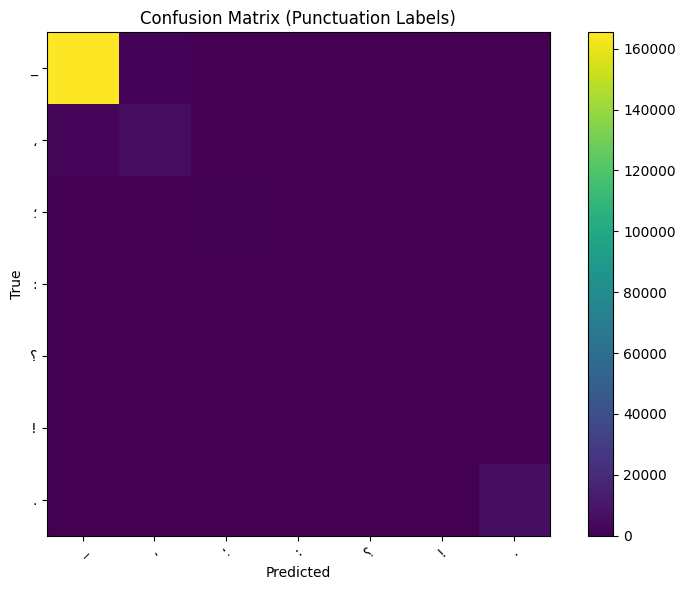

punct-only macro F1: 0.6870968019456135
punct-only weighted F1: 0.8524462366753408
present labels: [0, 1, 2, 3, 4, 6] ['_', '،', '؛', ':', '؟', '.']
present (no _): [1, 2, 3, 4, 6] ['،', '؛', ':', '؟', '.']
macro F1 (present punct only): 0.7993939337645525


In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
from transformers import AutoModelForTokenClassification, AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForTokenClassification.from_pretrained("best_model").to(device)
tokenizer = AutoTokenizer.from_pretrained("best_model", use_fast=True)


test_loader = DataLoader(test_ds, batch_size=16, collate_fn=collate_fn)

@torch.no_grad()
def collect_preds(model, loader, max_batches=400):
    model.eval()
    y_true, y_pred = [], []

    for i, batch in enumerate(loader):
        for k in batch:
            batch[k] = batch[k].to(device)

        out = model(**batch)
        preds = out.logits.argmax(dim=-1).detach().cpu().numpy()
        labels = batch["labels"].detach().cpu().numpy()

        for p_row, y_row in zip(preds, labels):
            for p, y in zip(p_row, y_row):
                if y == -100:
                    continue
                y_true.append(int(y))
                y_pred.append(int(p))

        if max_batches is not None and (i + 1) >= max_batches:
            break

    return np.array(y_true), np.array(y_pred)

y_true, y_pred = collect_preds(model, test_loader, max_batches=400)

print("Counts:", len(y_true))

labels_all = list(range(len(PUNC_VOCAB)))
print(classification_report(
    y_true, y_pred,
    labels=labels_all,
    target_names=[ID2PUNC[i] for i in labels_all],
    digits=4,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred, labels=labels_all)
plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (Punctuation Labels)")
plt.colorbar()
ticks = np.arange(len(PUNC_VOCAB))
plt.xticks(ticks, [ID2PUNC[i] for i in ticks], rotation=45)
plt.yticks(ticks, [ID2PUNC[i] for i in ticks])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

mask = (y_true != PUNC2ID["_"])
print("punct-only macro F1:", f1_score(y_true[mask], y_pred[mask], average="macro"))
print("punct-only weighted F1:", f1_score(y_true[mask], y_pred[mask], average="weighted"))

present_labels = sorted(set(y_true.tolist()))
present_no_underscore = [l for l in present_labels if l != PUNC2ID["_"]]
print("present labels:", present_labels, [ID2PUNC[i] for i in present_labels])
print("present (no _):", present_no_underscore, [ID2PUNC[i] for i in present_no_underscore])

print("macro F1 (present punct only):",
      f1_score(y_true, y_pred, labels=present_no_underscore, average="macro"))


ملاحظة :
اشارة التعجب عنا مشكلة فيها من وقت استكشاف البيانات بين معنا انو عددها كتير قليل بالنسبة للباقي والمودل ما لح يلاقيها ولأنو الداتا رسمية مافيها علامات تعجب

استكشاف لنسبة كل علامة





In [ ]:
from collections import Counter
import numpy as np

cnt = Counter(y_true.tolist())
total = sum(cnt.values())
for i in range(len(PUNC_VOCAB)):
    print(f"{ID2PUNC[i]:>2}  {cnt.get(i,0):>7}  {(cnt.get(i,0)/total)*100:6.2f}%")


 _   166858   91.11%
 ،     8283    4.52%
 ؛     1347    0.74%
 :      301    0.16%
 ؟       31    0.02%
 !        0    0.00%
 .     6314    3.45%


اشارة التعجب معدومة بالعينة يلي اخدناها

 Inference: استرجاع الترقيم لنص جديد

In [ ]:
def predict_punctuation(text: str, cfg: PreprocessConfig):
    proc = preprocess_line_cfg(text, cfg)
    toks, _ = line_to_tokens_labels(proc)
    if not toks:
        return text

    enc = tokenizer([toks], is_split_into_words=True, truncation=True, padding=True, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**enc)
    pred_ids = out.logits.argmax(dim=-1)[0].cpu().tolist()

    word_ids = enc.word_ids(batch_index=0)
    word_pred = []
    prev = None
    for pid, wid in zip(pred_ids, word_ids):
        if wid is None:
            continue
        if wid != prev:
            word_pred.append(pid)
        prev = wid

    out_words = []
    for w, pid in zip(toks, word_pred):
        p = ID2PUNC.get(pid, "_")
        if p != "_":
            out_words.append(w + " " + p)
        else:
            out_words.append(w)
    return " ".join(out_words)

sample = "هذا نص عربي بدون ترقيم مناسب كيف يمكن للنموذج ان يعيد الترقيم بطريقة جيدة"
print(predict_punctuation(sample, CFG))


هذا نص عربي بدون ترقيم مناسب ، كيف يمكن للنموذج ان يعيد الترقيم بطريقة جيدة ؟


حفظ افضل نموذج طلع معنا في التدريب على الدرايف تمهيدا للرفع

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
from pathlib import Path

def save_best_model_to_drive(
    model,
    tokenizer,
    drive_dir="/content/drive/MyDrive/punc_model",
    zip_name="best_model.zip"
):

    drive_dir = Path(drive_dir)
    drive_dir.mkdir(parents=True, exist_ok=True)

    model.save_pretrained(drive_dir)
    tokenizer.save_pretrained(drive_dir)

    zip_path = drive_dir.parent / zip_name
    if zip_path.exists():
        zip_path.unlink()

    shutil.make_archive(str(zip_path).replace(".zip",""), "zip", root_dir=str(drive_dir))

    print("✅ Saved folder:", drive_dir)
    print("✅ Saved zip   :", zip_path)
    return str(drive_dir), str(zip_path)

# folder_path, zip_path = save_best_model_to_drive(model, tokenizer)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from collections import Counter
import numpy as np
import torch
import torch.nn as nn

def count_labels_stream(ds, max_examples=200000):
    c = Counter()
    n = 0
    for ex in ds:
        c.update(ex["labels"])
        n += 1
        if max_examples and n >= max_examples:
            break
    return c

train_ds_for_count = PuncIterableDataset(train_files, CFG, max_lines=200000, buffer_shuffle=0)
counts = count_labels_stream(train_ds_for_count, max_examples=200000)

freq = np.array([counts.get(i, 1) for i in range(len(PUNC_VOCAB))], dtype=np.float64)

weights = (freq.sum() / freq)
weights = weights / weights.mean()

print({ID2PUNC[i]: float(weights[i]) for i in range(len(PUNC_VOCAB))})

w_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
weighted_ce = nn.CrossEntropyLoss(weight=w_tensor, ignore_index=-100)

def weighted_loss(logits, labels):
    return weighted_ce(logits.view(-1, logits.size(-1)), labels.view(-1))


{'_': 3.228158479676366e-05, '،': 0.0005945547261007151, '؛': 0.006595456649858522, ':': 0.018114389976236385, '؟': 0.17626302129075114, '!': 6.797621734125924, '.': 0.0007785616463321411}


توابع لتجربة النصوص والمقارنة
وتجربة النصوص من الداتا الطبية

In [ ]:
import difflib
import numpy as np
from sklearn.metrics import classification_report, f1_score, accuracy_score

def align_labels_by_tokens(gold_toks, gold_labs, pred_toks, pred_labs, pad_label=None):

    sm = difflib.SequenceMatcher(a=gold_toks, b=pred_toks, autojunk=False)
    y_true = []
    y_pred = []

    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == "equal":
            for i, j in zip(range(i1, i2), range(j1, j2)):
                y_true.append(gold_labs[i])
                y_pred.append(pred_labs[j])

        elif tag == "replace":
            n = min(i2 - i1, j2 - j1)
            for k in range(n):
                y_true.append(gold_labs[i1 + k])
                y_pred.append(pred_labs[j1 + k])


    return np.array(y_true, dtype=int), np.array(y_pred, dtype=int)


In [ ]:
import re

PUNC_CHARS = "،؛:؟!."

def remove_punctuation_from_text(text: str) -> str:
    text = re.sub(rf"[{re.escape(PUNC_CHARS)}]", "", text)
    return re.sub(r"\s+", " ", text).strip()

def detokenize_punctuation(spaced_text: str) -> str:
    spaced_text = re.sub(r"\s+([،؛:؟!.])", r"\1", spaced_text)
    spaced_text = re.sub(r"([،؛:؟!.])\s*", r"\1 ", spaced_text)
    return spaced_text.strip()


In [ ]:
import torch, re

@torch.no_grad()
def predict_punctuation_long_text(
    text: str,
    cfg: PreprocessConfig,
    max_length: int = 256,
    chunk_words: int = 180,
    overlap_words: int = 30,
):
    proc = preprocess_line_cfg(text, cfg)
    toks, _ = line_to_tokens_labels(proc)
    if not toks:
        return text

    out_chunks = []
    i = 0

    while i < len(toks):
        chunk = toks[i:i+chunk_words]

        enc = tokenizer(
            [chunk],
            is_split_into_words=True,
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt"
        )

        word_ids = enc.word_ids(batch_index=0)

        enc = enc.to(device)

        out = model(**enc)
        pred_ids = out.logits.argmax(dim=-1)[0].tolist()

        word_pred = []
        prev = None
        for pid, wid in zip(pred_ids, word_ids):
            if wid is None:
                continue
            if wid != prev:
                word_pred.append(pid)
            prev = wid

        parts = []
        for w, pid in zip(chunk, word_pred):
            p = ID2PUNC.get(pid, "_")
            parts.append(w if p == "_" else f"{w} {p}")
        out_chunks.append(" ".join(parts))

        if i + chunk_words >= len(toks):
            break
        i += (chunk_words - overlap_words)

    out_text = " ".join(out_chunks)
    out_text = re.sub(r"\s+", " ", out_text).strip()
    return detokenize_punctuation(out_text)


In [ ]:
!pip -q install datasets huggingface_hub pandas


In [ ]:
from datasets import load_dataset
from itertools import islice

DS_NAME = "Ahmed-Selem/Shifaa_Arabic_Medical_Consultations"


ds = load_dataset(DS_NAME, streaming=True)
print("Splits:", list(ds.keys()))

split_name = list(ds.keys())[0]
stream = ds[split_name]

first_ex = next(iter(stream))
print("Example keys:", list(first_ex.keys()))
print("Example (short):", {k: (str(v)[:120] + "..." if isinstance(v,str) and len(v)>120 else v) for k,v in first_ex.items()})

def guess_text_field(example: dict):
    preferred = ["text", "conversation", "consultation", "question", "prompt", "input", "content"]
    for k in preferred:
        if k in example and isinstance(example[k], str) and len(example[k].strip()) > 0:
            return k
    for k,v in example.items():
        if isinstance(v, str) and len(v.strip()) > 0:
            return k
    return None

TEXT_FIELD = guess_text_field(first_ex)
print("Guessed TEXT_FIELD:", TEXT_FIELD)


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Splits: ['train']
Example keys: ['Question Title', 'Question', 'Answer', 'Doctor Name', 'Consultation Number', 'Date of Answer', 'Hierarchical Diagnosis']
Example (short): {'Question Title': 'هل ارتفاع اليوزينيات في تحليل الدم تدل على أمر خطير؟', 'Question': 'السلام عليكم\nالشكر الجزيل لكل من يسهر على هذه المنصة.\n\nسؤالي -جزاكم الله خيراً-: هل ارتفاع اليوزينيات في تحليل الدم إلى ...', 'Answer': 'بسم الله الرحمن الرحيم\nالأخت الفاضلة/ مريم حفظها الله.\nالسلام عليكم ورحمة الله وبركاته، وبعد:\n\nاليوزينيات أو الحمضات أو ...', 'Doctor Name': 'د. عطية إبراهيم محمد', 'Consultation Number': 2549588, 'Date of Answer': '2024-09-19', 'Hierarchical Diagnosis': 'أمراض الدم والأورام - أمراض الدم - أخرى'}
Guessed TEXT_FIELD: Question Title


In [ ]:
import pandas as pd
from pathlib import Path

N = 300
OUT_DIR = Path("/content/drive/MyDrive/Shifaa_sample")
OUT_DIR.mkdir(parents=True, exist_ok=True)

stream = load_dataset(DS_NAME, streaming=True)[split_name]

rows = []
for ex in islice(stream, N):
    rows.append(ex)

df = pd.DataFrame(rows)
print("Saved sample shape:", df.shape)
print("Columns:", df.columns.tolist())

sample_path = OUT_DIR / f"{DS_NAME.split('/')[-1]}_{split_name}_sample_{N}.jsonl"
df.to_json(sample_path, orient="records", lines=True, force_ascii=False)
print("✅ Saved JSONL to:", sample_path)


Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Saved sample shape: (300, 7)
Columns: ['Question Title', 'Question', 'Answer', 'Doctor Name', 'Consultation Number', 'Date of Answer', 'Hierarchical Diagnosis']
✅ Saved JSONL to: /content/drive/MyDrive/Shifaa_sample/Shifaa_Arabic_Medical_Consultations_train_sample_300.jsonl


In [ ]:
from datasets import Dataset

hf_sample = Dataset.from_pandas(df)
disk_path = OUT_DIR / f"hf_saved_{split_name}_sample_{N}"
hf_sample.save_to_disk(str(disk_path))
print("✅ Saved Dataset to:", disk_path)


Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

✅ Saved Dataset to: /content/drive/MyDrive/Shifaa_sample/hf_saved_train_sample_300


In [ ]:
import torch
from transformers import AutoModelForTokenClassification, AutoTokenizer

MODEL_DIR = "/content/best_model"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForTokenClassification.from_pretrained(MODEL_DIR).to(device)
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, use_fast=True)

print("✅ model/tokenizer loaded from:", MODEL_DIR)
print("Device:", device)


✅ model/tokenizer loaded from: /content/best_model
Device: cuda


In [ ]:
import re

def safe_get_text(row: dict, text_field: str):
    if text_field and text_field in row and isinstance(row[text_field], str):
        return row[text_field]
    parts = []
    for k,v in row.items():
        if isinstance(v, str) and v.strip():
            parts.append(f"{k}: {v}")
    return "\n".join(parts)

RESULTS = []
for i, row in enumerate(rows[:N], start=1):
    gold = safe_get_text(row, TEXT_FIELD)

    inp = remove_punctuation_from_text(gold)

    pred = predict_punctuation_long_text(
        inp,
        cfg=CFG,
        max_length=256,
        chunk_words=180,
        overlap_words=30
    )

    RESULTS.append({
        "idx": i,
        "input_no_punc": inp,
        "predicted": pred,
        "original": gold
    })

res_df = pd.DataFrame(RESULTS)
print(res_df.head(3)[["idx"]])

csv_path = OUT_DIR / f"model_outputs_{split_name}_N{N}.csv"
jsonl_path = OUT_DIR / f"model_outputs_{split_name}_N{N}.jsonl"

res_df.to_csv(csv_path, index=False)
res_df.to_json(jsonl_path, orient="records", lines=True, force_ascii=False)

print("✅ Saved outputs CSV :", csv_path)
print("✅ Saved outputs JSONL:", jsonl_path)


   idx
0    1
1    2
2    3
✅ Saved outputs CSV : /content/drive/MyDrive/Shifaa_sample/model_outputs_train_N300.csv
✅ Saved outputs JSONL: /content/drive/MyDrive/Shifaa_sample/model_outputs_train_N300.jsonl


In [ ]:
k = 5
for j in range(k):
    print("="*80)
    print("ORIGINAL:\n", RESULTS[j]["original"][:800])
    print("\nINPUT (no punc):\n", RESULTS[j]["input_no_punc"][:800])
    print("\nPREDICTED:\n", RESULTS[j]["predicted"][:800])


ORIGINAL:
 هل ارتفاع اليوزينيات في تحليل الدم تدل على أمر خطير؟

INPUT (no punc):
 هل ارتفاع اليوزينيات في تحليل الدم تدل على أمر خطير

PREDICTED:
 هل ارتفاع اليوزينيات في تحليل الدم تدل على أمر خطير؟
ORIGINAL:
 هل يوجد إشكال في اختلاف فصيلة الدم بين الزوجين؟

INPUT (no punc):
 هل يوجد إشكال في اختلاف فصيلة الدم بين الزوجين

PREDICTED:
 هل يوجد إشكال في اختلاف فصيلة الدم بين الزوجين؟
ORIGINAL:
 اختلاف فصيلة دم الأم والطفل هل يؤثر على حياة الطفل؟

INPUT (no punc):
 اختلاف فصيلة دم الأم والطفل هل يؤثر على حياة الطفل

PREDICTED:
 اختلاف فصيلة دم الأم والطفل، هل يؤثر على حياة الطفل؟
ORIGINAL:
 عملية استئصال الطحال وعلاقتها بمرض الكريات الحمراء

INPUT (no punc):
 عملية استئصال الطحال وعلاقتها بمرض الكريات الحمراء

PREDICTED:
 عملية استئصال الطحال وعلاقتها بمرض الكريات الحمراء.
ORIGINAL:
 ما هي المدة اللازمة لعلاج طفلي من حمى البحر المتوسط؟

INPUT (no punc):
 ما هي المدة اللازمة لعلاج طفلي من حمى البحر المتوسط

PREDICTED:
 ما هي المدة اللازمة لعلاج طفلي من حمى البحر المتوسط؟


In [ ]:
results = [
  {
    "number_step": 1,
    "name_model": "CAMeL-Lab/bert-base-arabic-camelbert-mix",
    "features": "Token classification (sequence labeling) على مستوى الكلمة: إدخال كلمات بدون ترقيم، وإخراج label لعلامة الترقيم التالية لكل كلمة. PUNC_VOCAB=['_', '،', '؛', ':', '؟', '!', '.']",
    "parameters_model": {
      "batch_size": 16,
      "grad_accum": 2,
      "effective_batch": 32,
      "lr": 2e-5,
      "epochs": 2,
      "max_steps_per_epoch": 15000,
      "warmup_ratio": 0.06,
      "optimizer": "AdamW",
      "scheduler": "linear_warmup",
      "mixed_precision": "torch.cuda.amp"
    },
    "methods_preprocessing": [
      "PreprocessConfig / preprocess_line_cfg كما في مشروعك",
      "تحويل النص إلى tokens + labels عبر line_to_tokens_labels",
      "tokenize_and_align مع is_split_into_words=True + labels=-100 على subwords"
    ],
    "accuracy": 0.9717,
    "F-score": {
      "overall_macro_f1": 0.7078,
      "punct_only_macro_f1": 0.6965409425950176,
      "punct_only_weighted_f1": 0.879743052650383,
      "present_punct_macro_f1": 0.7937142511429427
    }
  },
  {
    "number_step": 2,
    "name_model": "aubmindlab/bert-base-arabertv2",
    "features": "Token classification (sequence labeling) على مستوى الكلمة: إدخال كلمات بدون ترقيم، وإخراج label لعلامة الترقيم التالية لكل كلمة. PUNC_VOCAB=['_', '،', '؛', ':', '؟', '!', '.']",
    "parameters_model": {
      "batch_size": 16,
      "grad_accum": 2,
      "effective_batch": 32,
      "lr": 2e-5,
      "epochs": 2,
      "max_steps_per_epoch": 5000,
      "warmup_ratio": 0.06,
      "optimizer": "AdamW",
      "scheduler": "linear_warmup",
      "mixed_precision": "torch.cuda.amp"
    },
    "methods_preprocessing": [
      "PreprocessConfig / preprocess_line_cfg كما في مشروعك",
      "تحويل النص إلى tokens + labels عبر line_to_tokens_labels",
      "tokenize_and_align مع is_split_into_words=True + labels=-100 على subwords"
    ],
    "accuracy": 0.9727,
    "F-score": {
      "overall_macro_f1": 0.7072,
      "overall_weighted_f1": 0.9725,
      "punct_only_macro_f1": 0.6969813048403616,
      "punct_only_weighted_f1": 0.8847323254773296,
      "present_punct_macro_f1": 0.7927905018267934
    }
  },
  {
    "number_step": 3,
    "name_model": "CAMeL-Lab/bert-base-arabic-camelbert-ca",
    "features": "Token classification (sequence labeling) على مستوى الكلمة: إدخال كلمات بدون ترقيم، وإخراج label لعلامة الترقيم التالية لكل كلمة. PUNC_VOCAB=['_', '،', '؛', ':', '؟', '!', '.']",
    "parameters_model": {
      "batch_size": 16,
      "grad_accum": 2,
      "effective_batch": 32,
      "lr": 2e-5,
      "epochs": 2,
      "max_steps_per_epoch": 15000,
      "warmup_ratio": 0.06,
      "optimizer": "AdamW",
      "scheduler": "linear_warmup",
      "mixed_precision": "torch.cuda.amp"
    },
    "methods_preprocessing": [
      "PreprocessConfig / preprocess_line_cfg كما في مشروعك",
      "تحويل النص إلى tokens + labels عبر line_to_tokens_labels",
      "tokenize_and_align مع is_split_into_words=True + labels=-100 على subwords"
    ],
    "accuracy": 0.9707,
    "F-score": {
      "overall_macro_f1": 0.7060,
      "overall_weighted_f1": 0.9701,
      "punct_only_macro_f1": 0.690242770947759,
      "punct_only_weighted_f1": 0.8657930608249478,
      "present_punct_macro_f1": 0.7914058365381234
    }
  }
]


In [ ]:
import pandas as pd
from IPython.display import display

def print_results_colab(results, sort_by="number_step", ascending=True, best_by="present_punct_macro_f1"):
    """
    results: list[dict] مثل الذي عندك
    يعرض جدول مباشرة في كولاب + يطبع أفضل نموذج حسب best_by
    """
    if not results:
        print("results فارغة.")
        return None

    rows = []
    for r in results:
        fs = r.get("F-score", {}) or {}

        row = {
            "number_step": r.get("number_step"),
            "name_model": r.get("name_model"),
            "accuracy": r.get("accuracy"),

            "present_punct_macro_f1": fs.get("present_punct_macro_f1"),
            "punct_only_macro_f1": fs.get("punct_only_macro_f1"),
            "punct_only_weighted_f1": fs.get("punct_only_weighted_f1"),
            "overall_macro_f1": fs.get("overall_macro_f1"),
            "overall_weighted_f1": fs.get("overall_weighted_f1"),

            "features": r.get("features"),
            "parameters_model": r.get("parameters_model"),
            "methods_preprocessing": r.get("methods_preprocessing"),
        }
        rows.append(row)

    df = pd.DataFrame(rows)

    if sort_by in df.columns:
        df = df.sort_values(by=sort_by, ascending=ascending).reset_index(drop=True)

    display(df)

    if best_by and best_by in df.columns and df[best_by].notna().any():
        best_idx = df[best_by].astype(float).idxmax()
        best = df.loc[best_idx]
        print(f"\n✅ Best model by `{best_by}`:")
        print("number_step:", best["number_step"])
        print("name_model :", best["name_model"])
        print(best_by, ":", best[best_by])

    return df


In [ ]:
df = show_results_table(results, sort_by="number_step", show_best_by="present_punct_macro_f1")


,number_step,name_model,accuracy,present_punct_macro_f1,punct_only_macro_f1,punct_only_weighted_f1,overall_macro_f1,overall_weighted_f1,parameters_model,methods_preprocessing
0,1,CAMeL-Lab/bert-base-arabic-camelbert-mix,0.9717,0.793714,0.696541,0.879743,0.7078,NaN,"{'batch_size': 16, 'grad_accum': 2, 'effective...",[PreprocessConfig / preprocess_line_cfg كما في...
1,2,aubmindlab/bert-base-arabertv2,0.9727,0.792791,0.696981,0.884732,0.7072,0.9725,"{'batch_size': 16, 'grad_accum': 2, 'effective...",[PreprocessConfig / preprocess_line_cfg كما في...
2,3,CAMeL-Lab/bert-base-arabic-camelbert-ca,0.9707,0.791406,0.690243,0.865793,0.7060,0.9701,"{'batch_size': 16, 'grad_accum': 2, 'effective...",[PreprocessConfig / preprocess_line_cfg كما في...



✅ Best by present_punct_macro_f1 :
number_step: 1
name_model : CAMeL-Lab/bert-base-arabic-camelbert-mix
present_punct_macro_f1: 0.7937142511429427
